# **Setup**

In [ ]:
!pip install kaggle

In [ ]:
# Upload Kaggle API token in the environment
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Get All the datasets

!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri
!unzip brain-tumor-classification-mri.zip -d brain-tumor-classification-mri-dataset

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip chest-xray-pneumonia.zip -d chest-xray-pneumonia

!kaggle datasets download -d fanconic/skin-cancer-malignant-vs-benign
!unzip skin-cancer-malignant-vs-benign.zip -d skin-cancer

# The setup in ultrasound should change
!kaggle datasets download -d vuppalaadithyasairam/ultrasound-breast-images-for-breast-cancer
!unzip ultrasound-breast-images-for-breast-cancer.zip -d ultrasound

Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri
License(s): MIT
Archive:  brain-tumor-classification-mri.zip
  inflating: brain-tumor-classification-mri-dataset/Testing/glioma_tumor/image(1).jpg  
  inflating: brain-tumor-classification-mri-dataset/Testing/glioma_tumor/image(10).jpg  
  inflating: brain-tumor-classification-mri-dataset/Testing/glioma_tumor/image(100).jpg  
  inflating: brain-tumor-classification-mri-dataset/Testing/glioma_tumor/image(11).jpg  
  inflating: brain-tumor-classification-mri-dataset/Testing/glioma_tumor/image(12).jpg  
  inflating: brain-tumor-classification-mri-dataset/Testing/glioma_tumor/image(13).jpg  
  inflating: brain-tumor-classification-mri-dataset/Testing/glioma_tumor/image(14).jpg  
  inflating: brain-tumor-classification-mri-dataset/Testing/glioma_tumor/image(15).jpg  
  inflating: brain-tumor-classification-mri-dataset/Testing/glioma_tumor/image(16).jpg  
  inflating: brain-tumor-classification-mri-data

In [ ]:
# Import Section
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, ResNet101
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import roc_auc_score
import numpy as np
import os

# **Helper Fucntions and Augmentation Implementations**


In [ ]:
def ece_score(py, y_test, n_bins=15):
    py = np.array(py)
    y_test = np.array(y_test)
    if y_test.ndim > 1:
        y_test = np.argmax(y_test, axis=1)
    py_index = np.argmax(py, axis=1)
    py_value = []
    for i in range(py.shape[0]):
        py_value.append(py[i, py_index[i]])
    py_value = np.array(py_value)
    acc, conf = np.zeros(n_bins), np.zeros(n_bins)
    Bm = np.zeros(n_bins)
    for m in range(n_bins):
        a, b = m / n_bins, (m + 1) / n_bins
        for i in range(py.shape[0]):
            if py_value[i] > a and py_value[i] <= b:
                Bm[m] += 1
                if py_index[i] == y_test[i]:
                    acc[m] += 1
                conf[m] += py_value[i]
        if Bm[m] != 0:
            acc[m] = acc[m] / Bm[m]
            conf[m] = conf[m] / Bm[m]
    ece = 0
    for m in range(n_bins):
        ece += Bm[m] * np.abs((acc[m] - conf[m]))
    return ece / sum(Bm)

In [ ]:
def cut_out(image, max_mask_size=50):
    h, w, _ = image.shape
    mask_size = 25
    x = np.random.randint(0, w - mask_size)
    y = np.random.randint(0, h - mask_size)
    image_copy = np.copy(image)
    image_copy[y:y+mask_size, x:x+mask_size, :] = 0

    return image_copy

In [ ]:
def cut_out_grid(image, mask_size=25, region='center'):
    h, w, _ = image.shape
    thirds_h = h // 3
    thirds_w = w // 3

    regions = {
        'top_left': (0, 0),
        'top_center': (thirds_w, 0),
        'top_right': (2 * thirds_w, 0),
        'center_left': (0, thirds_h),
        'center': (thirds_w, thirds_h),
        'center_right': (2 * thirds_w, thirds_h),
        'bottom_left': (0, 2 * thirds_h),
        'bottom_center': (thirds_w, 2 * thirds_h),
        'bottom_right': (2 * thirds_w, 2 * thirds_h),
    }

    x, y = regions[region]
    x += np.random.randint(0, thirds_w - mask_size)
    y += np.random.randint(0, thirds_h - mask_size)

    image_copy = np.copy(image)
    image_copy[y:y+mask_size, x:x+mask_size, :] = 0

    return image_copy

In [ ]:
import numpy as np

# This is from the open-source implementation at https://github.com/yu4u/mixup-generator
class MixupGenerator():
    def __init__(self, X_train, y_train, batch_size=32, alpha=0.2, shuffle=True, datagen=None):
        self.X_train = X_train
        self.y_train = y_train
        self.batch_size = batch_size
        self.alpha = alpha
        self.shuffle = shuffle
        self.sample_num = len(X_train)
        self.datagen = datagen

    def __call__(self):
        while True:
            indexes = self.__get_exploration_order()
            itr_num = int(len(indexes) // (self.batch_size * 2))

            for i in range(itr_num):
                batch_ids = indexes[i * self.batch_size * 2:(i + 1) * self.batch_size * 2]
                X, y = self.__data_generation(batch_ids)

                yield X, y

    def __get_exploration_order(self):
        indexes = np.arange(self.sample_num)

        if self.shuffle:
            np.random.shuffle(indexes)

        return indexes

    def __data_generation(self, batch_ids):
        _, h, w, c = self.X_train.shape
        l = np.random.beta(self.alpha, self.alpha, self.batch_size)
        X_l = l.reshape(self.batch_size, 1, 1, 1)
        y_l = l.reshape(self.batch_size, 1)

        X1 = self.X_train[batch_ids[:self.batch_size]]
        X2 = self.X_train[batch_ids[self.batch_size:]]
        X = X1 * X_l + X2 * (1 - X_l)

        if self.datagen:
            for i in range(self.batch_size):
                X[i] = self.datagen.random_transform(X[i])
                X[i] = self.datagen.standardize(X[i])

        if isinstance(self.y_train, list):
            y = []

            for y_train_ in self.y_train:
                y1 = y_train_[batch_ids[:self.batch_size]]
                y2 = y_train_[batch_ids[self.batch_size:]]
                y.append(y1 * y_l + y2 * (1 - y_l))
        else:
            y1 = self.y_train[batch_ids[:self.batch_size]]
            y2 = self.y_train[batch_ids[self.batch_size:]]
            y = y1 * y_l + y2 * (1 - y_l)

        return X, y

In [ ]:
import numpy as np

class CutMixGenerator():
    def __init__(self, X_train, y_train, batch_size=32, alpha=1.0, shuffle=True, datagen=None):
        self.X_train = X_train
        self.y_train = y_train
        self.batch_size = batch_size
        self.alpha = alpha
        self.shuffle = shuffle
        self.sample_num = len(X_train)
        self.datagen = datagen

    def __call__(self):
        while True:
            indexes = self.__get_exploration_order()
            itr_num = int(len(indexes) // (self.batch_size * 2))

            for i in range(itr_num):
                batch_ids = indexes[i * self.batch_size * 2:(i + 1) * self.batch_size * 2]
                X, y = self.__data_generation(batch_ids)

                yield X, y

    def __get_exploration_order(self):
        indexes = np.arange(self.sample_num)
        if self.shuffle:
            np.random.shuffle(indexes)
        return indexes

    def __data_generation(self, batch_ids):
        _, h, w, c = self.X_train.shape
        l = np.random.beta(self.alpha, self.alpha, self.batch_size)

        X1 = self.X_train[batch_ids[:self.batch_size]]
        X2 = self.X_train[batch_ids[self.batch_size:]]
        y1 = self.y_train[batch_ids[:self.batch_size]]
        y2 = self.y_train[batch_ids[self.batch_size:]]

        X = np.empty(X1.shape)
        y = l.reshape(self.batch_size, 1) * y1 + (1 - l.reshape(self.batch_size, 1)) * y2

        for i in range(self.batch_size):
            lam = l[i]
            bbx1, bby1, bbx2, bby2 = self.__rand_bbox(h, w, lam)

            X[i] = X1[i].copy()
            X[i][bby1:bby2, bbx1:bbx2, :] = X2[i][bby1:bby2, bbx1:bbx2, :]

            lam_actual = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (h * w))
            y[i] = lam_actual * y1[i] + (1 - lam_actual) * y2[i]

            if self.datagen:
                X[i] = self.datagen.random_transform(X[i])
                X[i] = self.datagen.standardize(X[i])

        return X, y

    def __rand_bbox(self, height, width, lam):
        cut_rat = 0.4
        cut_w = np.int32(width * cut_rat)
        cut_h = np.int32(height * cut_rat)

        cx = np.random.randint(width)
        cy = np.random.randint(height)

        bbx1 = np.clip(cx - cut_w // 2, 0, width)
        bby1 = np.clip(cy - cut_h // 2, 0, height)
        bbx2 = np.clip(cx + cut_w // 2, 0, width)
        bby2 = np.clip(cy + cut_h // 2, 0, height)

        return bbx1, bby1, bbx2, bby2

# **Baseline Models**:

# ***Breast UltraSound***

In [ ]:
train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80/20 split
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)


train_generator = train_val_datagen.flow_from_directory(
    '/content/ultrasound/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='training'
)


val_generator = train_val_datagen.flow_from_directory(
    '/content/ultrasound/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    '/content/ultrasound/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)
print("Class indices:", val_generator.class_indices)
print("Class indices:", test_generator.class_indices)

Found 6494 images belonging to 2 classes.
Found 1622 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
Class indices: {'benign': 0, 'malignant': 1}
Class indices: {'benign': 0, 'malignant': 1}
Class indices: {'benign': 0, 'malignant': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 52s 375ms/step - accuracy: 0.7139 - loss: 0.5713 - val_accuracy: 0.5049 - val_loss: 0.7056
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 33s 324ms/step - accuracy: 0.8329 - loss: 0.4025 - val_accuracy: 0.6221 - val_loss: 0.6934
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 28s 274ms/step - accuracy: 0.8506 - loss: 0.3584 - val_accuracy: 0.6215 - val_loss: 0.7401
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 42s 280ms/step - accuracy: 0.8835 - loss: 0.2974 - val_accuracy: 0.5586 - val_loss: 1.0287
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 28s 276ms/step - accuracy: 0.8989 - loss: 0.2568 - val_accuracy: 0.6060 - val_loss: 1.1649
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 41s 274ms/step - accuracy: 0.9159 - loss: 0.2189 - val_accuracy: 0.6313 - val_loss: 1.1638
Epoch 7/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 33s 323ms/step - accuracy: 0.9199 - loss: 0.2075 - val_accuracy: 0.6412 - val_loss: 0.9196
Epoch 8/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 36s 272ms/step - accuracy: 0.9406 - loss: 0

In [ ]:
# Save the model for futrue and history file
model.save('ultra_classifier.h5')
model.save('ultra_classifie.keras')
import json
with open('ultra_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 383ms/step - accuracy: 0.8043 - loss: 0.9351
Test Loss: 1.1272
Test Accuracy: 0.7944


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

print(y_true)

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 447ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [ ]:
_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 239ms/step
Expected Calibration Error (ECE): 0.1917


# ***Brain Tumor***

In [ ]:
train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80/20 split
)

train_generator = train_val_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

val_generator = train_val_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_generator.class_indices)
print("Class indices:", val_generator.class_indices)

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)   # Dropout layer to prevent overfitting
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 682ms/step - accuracy: 0.4906 - loss: 1.1707 - val_accuracy: 0.2932 - val_loss: 1.4419
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 258ms/step - accuracy: 0.6921 - loss: 0.7931 - val_accuracy: 0.3002 - val_loss: 1.4848
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 267ms/step - accuracy: 0.7544 - loss: 0.6527 - val_accuracy: 0.3072 - val_loss: 1.5587
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 266ms/step - accuracy: 0.7578 - loss: 0.6375 - val_accuracy: 0.3089 - val_loss: 1.7357
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 240ms/step - accuracy: 0.7968 - loss: 0.5460 - val_accuracy: 0.3211 - val_loss: 2.2494
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 257ms/step - accuracy: 0.7891 - loss: 0.5502 - val_accuracy: 0.3298 - val_loss: 2.3676
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 260ms/step - accuracy: 0.8199 - loss: 0.5009 - val_accuracy: 0.3386 - val_loss: 2.2990
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 259ms/step - accuracy: 0.8459 - loss: 0.4462 - val_a

In [ ]:
model.save('tumor_classifier.h5')
model.save('tumor_classifie.keras')
import json
with open('tumor_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Testing',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 394 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 427ms/step - accuracy: 0.5455 - loss: 4.7032
Test Loss: 3.3326
Test Accuracy: 0.6574


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

print(y_true)

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 916ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]
Test AUROC: 0.8422


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step
Expected Calibration Error (ECE): 0.3210


# ***Skin Cancer***



In [ ]:
# Load/Preprocess Dataset

train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training generator (80% of data from 'train')
train_generator = train_val_datagen.flow_from_directory(
    '/content/skin-cancer/train',
    target_size=(224, 224),  # Resizing all images to 224x224
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

# Validation generator (20% of data from 'train')
val_generator = train_val_datagen.flow_from_directory(
    '/content/skin-cancer/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_generator.class_indices)


Found 2110 images belonging to 2 classes.
Found 527 images belonging to 2 classes.
Class indices: {'benign': 0, 'malignant': 1}


In [ ]:
# Build the ResNet-50 Model
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)   # Dropout layer to prevent overfitting
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the model

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 31s 579ms/step - accuracy: 0.5452 - loss: 0.7259 - val_accuracy: 0.5465 - val_loss: 0.7059
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 27s 264ms/step - accuracy: 0.7086 - loss: 0.5796 - val_accuracy: 0.5674 - val_loss: 0.6861
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step - accuracy: 0.7544 - loss: 0.5026 - val_accuracy: 0.4535 - val_loss: 0.6928
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 264ms/step - accuracy: 0.7977 - loss: 0.4527 - val_accuracy: 0.4535 - val_loss: 0.7330
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 253ms/step - accuracy: 0.7865 - loss: 0.4494 - val_accuracy: 0.4535 - val_loss: 0.8010
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 270ms/step - accuracy: 0.8167 - loss: 0.4117 - val_accuracy: 0.4535 - val_loss: 0.9316
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 269ms/step - accuracy: 0.8162 - loss: 0.4008 - val_accuracy: 0.4535 - val_loss: 0.9232
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 261ms/step - accuracy: 0.8240 - loss: 0.3862 - val_

In [ ]:
# Save the model for futrue and history file
import json

model.save('skin_cancer_classifier.h5')
model.save('skin_cancer_classifier.keras')

with open('skin_cancer_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
# Load Testing data and evaluate on the test dataset

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/skin-cancer/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 660 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step - accuracy: 0.7514 - loss: 0.8418
Test Loss: 0.6604
Test Accuracy: 0.8045


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step
Test AUROC: 0.8948


In [ ]:
# Compute ECE [Binary]

def ece_score(py, y_test, n_bins=15):
    py = np.array(py)
    y_test = np.array(y_test)
    if y_test.ndim > 1:
        y_test = np.argmax(y_test, axis=1)
    py_index = np.argmax(py, axis=1)
    py_value = []
    for i in range(py.shape[0]):
        py_value.append(py[i, py_index[i]])
    py_value = np.array(py_value)
    acc, conf = np.zeros(n_bins), np.zeros(n_bins)
    Bm = np.zeros(n_bins)
    for m in range(n_bins):
        a, b = m / n_bins, (m + 1) / n_bins
        for i in range(py.shape[0]):
            if py_value[i] > a and py_value[i] <= b:
                Bm[m] += 1
                if py_index[i] == y_test[i]:
                    acc[m] += 1
                conf[m] += py_value[i]
        if Bm[m] != 0:
            acc[m] = acc[m] / Bm[m]
            conf[m] = conf[m] / Bm[m]
    ece = 0
    for m in range(n_bins):
        ece += Bm[m] * np.abs((acc[m] - conf[m]))
    return ece / sum(Bm)

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step
0.16844238476319748
Expected Calibration Error (ECE): 0.1684


# ***CXR***

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
)
val_datagen = ImageDataGenerator(
    rescale=1./255,
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/val',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 66s 649ms/step - accuracy: 0.7854 - loss: 0.4656 - val_accuracy: 0.5000 - val_loss: 0.7154
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 73s 588ms/step - accuracy: 0.9412 - loss: 0.1874 - val_accuracy: 0.5000 - val_loss: 1.1879
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 48s 588ms/step - accuracy: 0.9585 - loss: 0.1356 - val_accuracy: 0.5000 - val_loss: 1.3442
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 80s 567ms/step - accuracy: 0.9678 - loss: 0.1043 - val_accuracy: 0.5000 - val_loss: 1.6835
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 48s 587ms/step - accuracy: 0.9728 - loss: 0.0859 - val_accuracy: 0.5000 - val_loss: 1.7669
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 47s 567ms/step - accuracy: 0.9714 - loss: 0.0867 - val_accuracy: 0.5625 - val_loss: 1.5363
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 47s 572ms/step - accuracy: 0.9728 - loss: 0.0801 - val_accuracy: 0.6875 - val_loss: 0.7265
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 48s 583ms/step - accuracy: 0.9740 - loss: 0.0754 - val_accu

In [ ]:
# Helper Function for ECE

def ece_score(py, y_test, n_bins=15):
    py = np.array(py)
    y_test = np.array(y_test)
    if y_test.ndim > 1:
        y_test = np.argmax(y_test, axis=1)
    py_index = np.argmax(py, axis=1)
    py_value = []
    for i in range(py.shape[0]):
        py_value.append(py[i, py_index[i]])
    py_value = np.array(py_value)
    acc, conf = np.zeros(n_bins), np.zeros(n_bins)
    Bm = np.zeros(n_bins)
    for m in range(n_bins):
        a, b = m / n_bins, (m + 1) / n_bins
        for i in range(py.shape[0]):
            if py_value[i] > a and py_value[i] <= b:
                Bm[m] += 1
                if py_index[i] == y_test[i]:
                    acc[m] += 1
                conf[m] += py_value[i]
        if Bm[m] != 0:
            acc[m] = acc[m] / Bm[m]
            conf[m] = conf[m] / Bm[m]
    ece = 0
    for m in range(n_bins):
        ece += Bm[m] * np.abs((acc[m] - conf[m]))
    return ece / sum(Bm)

In [ ]:
# Save the model for futrue and history file
model.save('cxr_classifier.h5')
model.save('cxr_classifie.keras')
import json
with open('cxr_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 557ms/step - accuracy: 0.7091 - loss: 1.8022
Test Loss: 1.1615
Test Accuracy: 0.8061


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 787ms/step
Test AUROC: 0.8638


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 442ms/step
Expected Calibration Error (ECE): 0.1862


# **CutOut Models**

# ***Breast UltraSound - Cutout Random***

In [ ]:
# Load/Preprocess Dataset

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2 ,
    preprocessing_function=lambda x: cut_out(x)
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)

# Training generator (80%)
train_generator = train_datagen.flow_from_directory(
    '/content/ultrasound/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

# Validation generator (20%)
val_generator = val_datagen.flow_from_directory(
    '/content/ultrasound/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    '/content/ultrasound/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)
print("Class indices:", val_generator.class_indices)
print("Class indices:", test_generator.class_indices)

Found 6494 images belonging to 2 classes.
Found 1622 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
Class indices: {'benign': 0, 'malignant': 1}
Class indices: {'benign': 0, 'malignant': 1}
Class indices: {'benign': 0, 'malignant': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 64s 425ms/step - accuracy: 0.7029 - loss: 0.5842 - val_accuracy: 0.5080 - val_loss: 0.6889
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 33s 323ms/step - accuracy: 0.8306 - loss: 0.4092 - val_accuracy: 0.5055 - val_loss: 0.7195
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 36s 273ms/step - accuracy: 0.8421 - loss: 0.3724 - val_accuracy: 0.5271 - val_loss: 0.8293
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 41s 273ms/step - accuracy: 0.8611 - loss: 0.3323 - val_accuracy: 0.6418 - val_loss: 0.6828
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 28s 273ms/step - accuracy: 0.8847 - loss: 0.2908 - val_accuracy: 0.5783 - val_loss: 0.9102
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 28s 275ms/step - accuracy: 0.8883 - loss: 0.2872 - val_accuracy: 0.5962 - val_loss: 0.8940
Epoch 7/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 28s 272ms/step - accuracy: 0.9122 - loss: 0.2420 - val_accuracy: 0.5771 - val_loss: 1.1632
Epoch 8/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 41s 272ms/step - accuracy: 0.9109 - loss: 0

In [ ]:
# Save the model for futrue and history file
model.save('ultra_cutout_classifier.h5')
model.save('ultra_cutout_classifie.keras')
import json
with open('ultra_cutout_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 367ms/step - accuracy: 0.6734 - loss: 1.3150
Test Loss: 1.1922
Test Accuracy: 0.7200


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

print(y_true)

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',    # one-vs-rest
    average='macro'       # macro-average across classes
)

print(f"Test AUROC: {auroc:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 444ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 201ms/step
Expected Calibration Error (ECE): 0.2527


# ***UltraSound - Cutout Center Left***

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2 ,
    preprocessing_function=lambda x: cut_out_grid(x, mask_size=25, region='center_left')
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)

# Training generator (80%)
train_generator = train_datagen.flow_from_directory(
    '/content/ultrasound/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

# Validation generator (20%)
val_generator = val_datagen.flow_from_directory(
    '/content/ultrasound/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    '/content/ultrasound/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)
print("Class indices:", val_generator.class_indices)
print("Class indices:", test_generator.class_indices)

Found 6494 images belonging to 2 classes.
Found 1622 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
Class indices: {'benign': 0, 'malignant': 1}
Class indices: {'benign': 0, 'malignant': 1}
Class indices: {'benign': 0, 'malignant': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
# Train the model

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 68s 429ms/step - accuracy: 0.7030 - loss: 0.6006 - val_accuracy: 0.5068 - val_loss: 0.6970
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 56s 293ms/step - accuracy: 0.8305 - loss: 0.4063 - val_accuracy: 0.4988 - val_loss: 0.9352
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 40s 281ms/step - accuracy: 0.8534 - loss: 0.3643 - val_accuracy: 0.5037 - val_loss: 1.1240
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 42s 289ms/step - accuracy: 0.8664 - loss: 0.3166 - val_accuracy: 0.6005 - val_loss: 0.7054
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 29s 281ms/step - accuracy: 0.8890 - loss: 0.2790 - val_accuracy: 0.5734 - val_loss: 1.2415
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 34s 331ms/step - accuracy: 0.8942 - loss: 0.2588 - val_accuracy: 0.5875 - val_loss: 1.0286
Epoch 7/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 29s 288ms/step - accuracy: 0.9190 - loss: 0.2165 - val_accuracy: 0.6005 - val_loss: 0.9612
Epoch 8/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 28s 274ms/step - accuracy: 0.9196 - loss: 0

In [ ]:
# Save the model for futrue and history file
model.save('ultra_cutout_centerLeft_classifier.h5')
model.save('ultra_cutout_centerLeft_classifie.keras')
import json
with open('ultra_cutout_centerLeft_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 382ms/step - accuracy: 0.7656 - loss: 1.2342
Test Loss: 1.3061
Test Accuracy: 0.7744


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

print(y_true)

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 443ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 194ms/step
Expected Calibration Error (ECE): 0.2102


# ***Skin Cancer - Cutout Random***

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    preprocessing_function=lambda x: cut_out(x)
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    '/content/skin-cancer/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    '/content/skin-cancer/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_generator.class_indices)

Found 2110 images belonging to 2 classes.
Found 527 images belonging to 2 classes.
Class indices: {'benign': 0, 'malignant': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 46s 777ms/step - accuracy: 0.5535 - loss: 0.7205 - val_accuracy: 0.4535 - val_loss: 0.7293
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 254ms/step - accuracy: 0.6510 - loss: 0.6210 - val_accuracy: 0.4535 - val_loss: 0.7487
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 247ms/step - accuracy: 0.7268 - loss: 0.5574 - val_accuracy: 0.4535 - val_loss: 0.7543
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 246ms/step - accuracy: 0.7340 - loss: 0.5075 - val_accuracy: 0.4535 - val_loss: 0.8712
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 258ms/step - accuracy: 0.7826 - loss: 0.4676 - val_accuracy: 0.4535 - val_loss: 0.8668
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 262ms/step - accuracy: 0.8008 - loss: 0.4355 - val_accuracy: 0.4535 - val_loss: 1.0073
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 250ms/step - accuracy: 0.8124 - loss: 0.4094 - val_accuracy: 0.4535 - val_loss: 1.2060
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 277ms/step - accuracy: 0.8059 - loss: 0.4192 - val_

In [ ]:
# Save the model for futrue and history file
model.save('skin_cancer_cutout_classifier.h5')
model.save('skin_cancer_cutout_classifie.keras')
import json
with open('skin_cutout_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/skin-cancer/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 660 images belonging to 2 classes.
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 471ms/step - accuracy: 0.8333 - loss: 0.4546
Test Loss: 0.4862
Test Accuracy: 0.8288


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 554ms/step
Test AUROC: 0.9181


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step
Expected Calibration Error (ECE): 0.1311


# ***Skin Cancer - Cutout Center***

In [ ]:
# Data generator for training with cutout
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    preprocessing_function=lambda x: cut_out_grid(x, mask_size=25, region='center')
)

# Data generator for validation without cutout
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    '/content/skin-cancer/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    '/content/skin-cancer/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_generator.class_indices)

Found 2110 images belonging to 2 classes.
Found 527 images belonging to 2 classes.
Class indices: {'benign': 0, 'malignant': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the model

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 42s 902ms/step - accuracy: 0.5977 - loss: 0.6965 - val_accuracy: 0.5465 - val_loss: 0.7102
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 16s 263ms/step - accuracy: 0.6992 - loss: 0.5699 - val_accuracy: 0.5787 - val_loss: 0.6895
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step - accuracy: 0.7831 - loss: 0.4798 - val_accuracy: 0.5693 - val_loss: 0.6829
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step - accuracy: 0.8002 - loss: 0.4430 - val_accuracy: 0.4535 - val_loss: 0.7434
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 243ms/step - accuracy: 0.8052 - loss: 0.4393 - val_accuracy: 0.4535 - val_loss: 0.7828
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 257ms/step - accuracy: 0.8235 - loss: 0.4013 - val_accuracy: 0.4535 - val_loss: 0.9236
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 258ms/step - accuracy: 0.8168 - loss: 0.4125 - val_accuracy: 0.4535 - val_loss: 1.0281
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 274ms/step - accuracy: 0.8285 - loss: 0.3958 - va

In [ ]:
# Save the model for futrue and history file
model.save('skin_cutout_center_classifier.h5')
model.save('skin_cutout_center_classifie.keras')
import json
with open('skin_cutout_center_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/skin-cancer/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 660 images belonging to 2 classes.
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 515ms/step - accuracy: 0.8525 - loss: 0.4628
Test Loss: 0.7835
Test Accuracy: 0.7591


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 585ms/step
Test AUROC: 0.8861


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step
Expected Calibration Error (ECE): 0.1968


# ***Tumor - Cutout Random***

In [ ]:
# Load/Preprocess Dataset

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    preprocessing_function=lambda x: cut_out(x)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

train_generator = train_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

# Validation generator (20%)
val_generator = val_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_generator.class_indices)
print("Class indices:", val_generator.class_indices)

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)   # Dropout layer to prevent overfitting
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# New training thing
# Train the model

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

In [ ]:
# Save the model for futrue and history file
model.save('tumor_cutout_classifier.h5')
model.save('tumor_cutout_classifie.keras')
import json
with open('tumor_cutout_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Testing',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 394 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.5097 - loss: 5.5614
Test Loss: 3.9736
Test Accuracy: 0.6066


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

print(y_true)

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',    # one-vs-rest
    average='macro'       # macro-average across classes
)

print(f"Test AUROC: {auroc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 754ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]
Test AUROC: 0.8247


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step
Expected Calibration Error (ECE): 0.3625


# ***Tumor - CutOut Center Left***

In [ ]:
# Load/Preprocess Dataset

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    preprocessing_function=lambda x: cut_out_grid(x, mask_size=25, region='center_left')
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

train_generator = train_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

# Validation generator (20%)
val_generator = val_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_generator.class_indices)
print("Class indices:", val_generator.class_indices)

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 565ms/step - accuracy: 0.4644 - loss: 1.3010 - val_accuracy: 0.2862 - val_loss: 1.8243
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step - accuracy: 0.6839 - loss: 0.8340 - val_accuracy: 0.2862 - val_loss: 1.5814
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 251ms/step - accuracy: 0.7158 - loss: 0.7289 - val_accuracy: 0.4206 - val_loss: 1.4510
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 253ms/step - accuracy: 0.7421 - loss: 0.6565 - val_accuracy: 0.2897 - val_loss: 1.9780
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 258ms/step - accuracy: 0.7812 - loss: 0.5884 - val_accuracy: 0.3072 - val_loss: 2.2728
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 259ms/step - accuracy: 0.7959 - loss: 0.5501 - val_accuracy: 0.3106 - val_loss: 2.5272
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 257ms/step - accuracy: 0.8061 - loss: 0.5165 - val_accuracy: 0.3124 - val_loss: 2.5470
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 248ms/step - accuracy: 0.8168 - loss: 0.5048 - va

In [ ]:
# Save the model for futrue and history file
model.save('tumor_cutout_centerLeft_classifier.h5')
model.save('tumor_cutout_centerLeft_classifie.keras')
import json
with open('tumor_cutout_centerLeft_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Testing',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 394 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 406ms/step - accuracy: 0.5491 - loss: 5.3965
Test Loss: 3.6144
Test Accuracy: 0.6650


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

print(y_true)

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',    # one-vs-rest
    average='macro'       # macro-average across classes
)

print(f"Test AUROC: {auroc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 813ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]
Test AUROC: 0.8330


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step
Expected Calibration Error (ECE): 0.3073


# ***CXR - Cutout Random***

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=lambda x: cut_out(x)
)
val_datagen = ImageDataGenerator(
    rescale=1./255,
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/val',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 75s 755ms/step - accuracy: 0.7809 - loss: 0.4627 - val_accuracy: 0.5000 - val_loss: 0.7893
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 68s 636ms/step - accuracy: 0.9224 - loss: 0.2127 - val_accuracy: 0.5000 - val_loss: 1.8068
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 80s 614ms/step - accuracy: 0.9521 - loss: 0.1444 - val_accuracy: 0.5000 - val_loss: 1.8505
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 83s 633ms/step - accuracy: 0.9556 - loss: 0.1191 - val_accuracy: 0.5000 - val_loss: 2.3724
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 81s 619ms/step - accuracy: 0.9640 - loss: 0.1065 - val_accuracy: 0.6250 - val_loss: 1.4020
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 51s 624ms/step - accuracy: 0.9672 - loss: 0.0969 - val_accuracy: 0.6875 - val_loss: 0.7705
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 82s 626ms/step - accuracy: 0.9667 - loss: 0.0900 - val_accuracy: 0.6250 - val_loss: 1.3105
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 80s 605ms/step - accuracy: 0.9749 - loss: 0.0803 - val_accu

In [ ]:
# Save the model for futrue and history file
model.save('cxr_cutout_classifier.h5')
model.save('cxr_cutout_classifie.keras')
import json
with open('cxr_cutout_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 536ms/step - accuracy: 0.5833 - loss: 2.4026
Test Loss: 1.4324
Test Accuracy: 0.7548


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 814ms/step
Test AUROC: 0.8926


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 466ms/step
Expected Calibration Error (ECE): 0.2328


# ***CXR - Cutout Center***

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=lambda x: cut_out_grid(x, mask_size=25, region='center')
)
val_datagen = ImageDataGenerator(
    rescale=1./255,
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/val',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 84s 784ms/step - accuracy: 0.7526 - loss: 0.5022 - val_accuracy: 0.5000 - val_loss: 0.7165
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 57s 622ms/step - accuracy: 0.9273 - loss: 0.2182 - val_accuracy: 0.5000 - val_loss: 0.6645
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 51s 617ms/step - accuracy: 0.9430 - loss: 0.1674 - val_accuracy: 0.8125 - val_loss: 0.5569
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 81s 610ms/step - accuracy: 0.9599 - loss: 0.1299 - val_accuracy: 0.8125 - val_loss: 0.4741
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 50s 613ms/step - accuracy: 0.9612 - loss: 0.1190 - val_accuracy: 0.7500 - val_loss: 0.4807
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 50s 614ms/step - accuracy: 0.9732 - loss: 0.0931 - val_accuracy: 0.7500 - val_loss: 0.4262
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 51s 618ms/step - accuracy: 0.9725 - loss: 0.0918 - val_accuracy: 0.8125 - val_loss: 0.4972
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 50s 612ms/step - accuracy: 0.9708 - loss: 0.0836 - val_accu

In [ ]:
# Save the model for futrue and history file
model.save('cxr_cutout_center_classifier.h5')
model.save('cxr_cutout_center_classifie.keras')
import json
with open('cxr_cutout_center_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 880ms/step - accuracy: 0.4657 - loss: 4.0169
Test Loss: 2.3734
Test Accuracy: 0.6955


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 807ms/step
Test AUROC: 0.8106


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 433ms/step
Expected Calibration Error (ECE): 0.2987


# ***CXR - Cutout Center Left***

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=lambda x: cut_out_grid(x, mask_size=25, region='center_left')
)
val_datagen = ImageDataGenerator(
    rescale=1./255,
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/val',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 84s 779ms/step - accuracy: 0.8159 - loss: 0.4229 - val_accuracy: 0.6875 - val_loss: 0.6821
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 50s 612ms/step - accuracy: 0.9461 - loss: 0.1589 - val_accuracy: 0.6250 - val_loss: 0.6447
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 82s 612ms/step - accuracy: 0.9570 - loss: 0.1249 - val_accuracy: 0.7500 - val_loss: 0.5867
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 82s 616ms/step - accuracy: 0.9703 - loss: 0.0946 - val_accuracy: 0.5625 - val_loss: 0.9925
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 50s 611ms/step - accuracy: 0.9710 - loss: 0.0863 - val_accuracy: 0.6875 - val_loss: 0.6652
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 82s 609ms/step - accuracy: 0.9748 - loss: 0.0768 - val_accuracy: 0.7500 - val_loss: 0.4607
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 82s 607ms/step - accuracy: 0.9699 - loss: 0.0848 - val_accuracy: 0.6875 - val_loss: 0.6816
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 51s 614ms/step - accuracy: 0.9807 - loss: 0.0594 - val_accu

In [ ]:
# Save the model for futrue and history file
model.save('cxr_cutout_centerLeft_classifier.h5')
model.save('cxr_cutout_centerLeft_classifie.keras')
import json
with open('cxr_cutout_center_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 952ms/step - accuracy: 0.4809 - loss: 3.5219
Test Loss: 2.0684
Test Accuracy: 0.7051


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 771ms/step
Test AUROC: 0.8358


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 519ms/step
Expected Calibration Error (ECE): 0.2862


# **CutMix Models**

# ***Breast UltraSound - CutMix Alpha = 0.8***

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80/20 split
)

temp_gen = train_datagen.flow_from_directory(
    '/content/ultrasound/train',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    subset='training'
)

train_generator = train_datagen.flow_from_directory(
    '/content/ultrasound/train',
    target_size=(224, 224),
    batch_size=temp_gen.samples,
    class_mode='categorical',
    subset='training',
    shuffle=False
)

X_train, y_train = next(train_generator)
print(X_train.shape)
print(y_train.shape)

cutmix_generator = CutMixGenerator(X_train, y_train, batch_size=64, alpha=0.8)()

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80/20 split
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)


# Validation generator (20%)
val_generator = val_datagen.flow_from_directory(
    '/content/ultrasound/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    '/content/ultrasound/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)
print("Class indices:", val_generator.class_indices)
print("Class indices:", test_generator.class_indices)

Found 6494 images belonging to 2 classes.
Found 6494 images belonging to 2 classes.
(6494, 224, 224, 3)
(6494, 2)
Found 1622 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
Class indices: {'benign': 0, 'malignant': 1}
Class indices: {'benign': 0, 'malignant': 1}
Class indices: {'benign': 0, 'malignant': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history = model.fit(
    cutmix_generator,
    validation_data=val_generator,
    epochs=50,
    steps_per_epoch=len(X_train) // 64,
    validation_steps=len(val_generator)
)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.6809 - loss: 0.6274

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


101/101 ━━━━━━━━━━━━━━━━━━━━ 57s 334ms/step - accuracy: 0.6814 - loss: 0.6269 - val_accuracy: 0.6104 - val_loss: 0.6864
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 26s 258ms/step - accuracy: 0.7919 - loss: 0.5224 - val_accuracy: 0.6350 - val_loss: 0.6781
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 27s 264ms/step - accuracy: 0.8143 - loss: 0.4910 - val_accuracy: 0.5567 - val_loss: 0.6730
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 27s 266ms/step - accuracy: 0.8245 - loss: 0.4734 - val_accuracy: 0.5660 - val_loss: 0.6913
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 26s 259ms/step - accuracy: 0.8467 - loss: 0.4528 - val_accuracy: 0.5721 - val_loss: 0.7801
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 26s 263ms/step - accuracy: 0.8472 - loss: 0.4424 - val_accuracy: 0.5882 - val_loss: 0.7847
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 27s 263ms/step - accuracy: 0.8656 - loss: 0.4286 - val_accuracy: 0.5900 - val_loss: 0.8147
Epoch 8/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 27s 264ms/step - accuracy: 0.8651 - loss: 0.4193 - val

In [ ]:
# Save the model for futrue and history file
model.save('ultra_cutmix8.h5')
model.save('ultra_cutmix8.keras')
import json
with open('ultra_cutmix8_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 416ms/step - accuracy: 0.8643 - loss: 0.3574
Test Loss: 0.4775
Test Accuracy: 0.8144


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

print(y_true)

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 497ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 251ms/step
Expected Calibration Error (ECE): 0.1189


# ***Breast UltraSound - CutMix Alpha = 0.4***

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

temp_gen = train_datagen.flow_from_directory(
    '/content/ultrasound/train',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    subset='training'
)

train_generator = train_datagen.flow_from_directory(
    '/content/ultrasound/train',
    target_size=(224, 224),
    batch_size=temp_gen.samples,
    class_mode='categorical',
    subset='training',
    shuffle=False
)

X_train, y_train = next(train_generator)
print(X_train.shape)
print(y_train.shape)

cutmix_generator = CutMixGenerator(X_train, y_train, batch_size=64, alpha=0.4)()

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)


val_generator = val_datagen.flow_from_directory(
    '/content/ultrasound/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    '/content/ultrasound/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)
print("Class indices:", val_generator.class_indices)
print("Class indices:", test_generator.class_indices)

Found 6494 images belonging to 2 classes.
Found 6494 images belonging to 2 classes.
(6494, 224, 224, 3)
(6494, 2)
Found 1622 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
Class indices: {'benign': 0, 'malignant': 1}
Class indices: {'benign': 0, 'malignant': 1}
Class indices: {'benign': 0, 'malignant': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(
    cutmix_generator,
    validation_data=val_generator,
    epochs=50,
    steps_per_epoch=len(X_train) // 64,
    validation_steps=len(val_generator)
)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.6763 - loss: 0.6282

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


101/101 ━━━━━━━━━━━━━━━━━━━━ 49s 347ms/step - accuracy: 0.6768 - loss: 0.6278 - val_accuracy: 0.5031 - val_loss: 0.7044
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 26s 262ms/step - accuracy: 0.7795 - loss: 0.5303 - val_accuracy: 0.5647 - val_loss: 0.6718
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 26s 260ms/step - accuracy: 0.8120 - loss: 0.4949 - val_accuracy: 0.5654 - val_loss: 0.6607
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 26s 261ms/step - accuracy: 0.8241 - loss: 0.4720 - val_accuracy: 0.5518 - val_loss: 0.7389
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 26s 259ms/step - accuracy: 0.8332 - loss: 0.4578 - val_accuracy: 0.5629 - val_loss: 0.7703
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 26s 262ms/step - accuracy: 0.8543 - loss: 0.4368 - val_accuracy: 0.6597 - val_loss: 0.7042
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 27s 264ms/step - accuracy: 0.8675 - loss: 0.4252 - val_accuracy: 0.6615 - val_loss: 0.6822
Epoch 8/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 27s 263ms/step - accuracy: 0.8642 - loss: 0.4170 - val

In [ ]:
# Save the model for futrue and history file
model.save('ultra_cutmix4.h5')
model.save('ultra_cutmix4.keras')
import json
with open('ultra_cutmix4_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 197ms/step - accuracy: 0.6926 - loss: 0.6820
Test Loss: 0.6213
Test Accuracy: 0.7200


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

print(y_true)

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 493ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 208ms/step
Expected Calibration Error (ECE): 0.2071


# ***Skin Cancer - CutMix Alpha = 0.8***

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

temp_gen = datagen.flow_from_directory(
    '/content/skin-cancer/train',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    subset='training'
)

train_generator = datagen.flow_from_directory(
    '/content/skin-cancer/train',
    target_size=(224, 224),
    batch_size=temp_gen.samples,
    class_mode='categorical',
    subset='training',
    shuffle=False
)

X_train, y_train = next(train_generator)
print(X_train.shape)
print(y_train.shape)

cutmix_generator = CutMixGenerator(X_train, y_train, batch_size=64, alpha=0.8)()

Found 2110 images belonging to 2 classes.
Found 2110 images belonging to 2 classes.
(2110, 224, 224, 3)
(2110, 2)


In [ ]:
# Data generator for validation without cutmix
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


val_generator = val_datagen.flow_from_directory(
    '/content/skin-cancer/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", val_generator.class_indices)

Found 527 images belonging to 2 classes.
Class indices: {'benign': 0, 'malignant': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history = model.fit(
    cutmix_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch=len(X_train) // 64,
    validation_steps=len(val_generator)
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.5367 - loss: 0.7167

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 588ms/step - accuracy: 0.5382 - loss: 0.7157 - val_accuracy: 0.4649 - val_loss: 0.6908
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 230ms/step - accuracy: 0.6777 - loss: 0.6236 - val_accuracy: 0.4535 - val_loss: 0.7095
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 235ms/step - accuracy: 0.7042 - loss: 0.5932 - val_accuracy: 0.4535 - val_loss: 0.7655
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 241ms/step - accuracy: 0.7278 - loss: 0.5718 - val_accuracy: 0.4535 - val_loss: 0.8248
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 232ms/step - accuracy: 0.7480 - loss: 0.5517 - val_accuracy: 0.4535 - val_loss: 0.9034
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 243ms/step - accuracy: 0.7535 - loss: 0.5260 - val_accuracy: 0.4535 - val_loss: 0.9190
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 242ms/step - accuracy: 0.7969 - loss: 0.5041 - val_accuracy: 0.4535 - val_loss: 1.0592
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step - accuracy: 0.7986 - loss: 0.4982 - val_accuracy: 0.453

In [ ]:
# Save the model for futrue and history file
model.save('skin_cutmix_alpha8.h5')
model.save('skin_cutmix_alpha8.keras')
import json
with open('skin_cutmix_alpha8_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
# Load Testing data and evaluate on the test dataset

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/skin-cancer/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 660 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 484ms/step - accuracy: 0.8193 - loss: 0.3466
Test Loss: 0.3715
Test Accuracy: 0.8182


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 571ms/step
Test AUROC: 0.9143


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step
Expected Calibration Error (ECE): 0.0879


# ***Skin Cancer - CutMix Alpha = 0.4***

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

temp_gen = datagen.flow_from_directory(
    '/content/skin-cancer/train',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    subset='training'
)

train_generator = datagen.flow_from_directory(
    '/content/skin-cancer/train',
    target_size=(224, 224),
    batch_size=temp_gen.samples,  # BIG batch_size to load everything at once
    class_mode='categorical',
    subset='training',
    shuffle=False
)

X_train, y_train = next(train_generator)
print(X_train.shape)
print(y_train.shape)

cutmix_generator = CutMixGenerator(X_train, y_train, batch_size=64, alpha=0.4)()

Found 2110 images belonging to 2 classes.
Found 2110 images belonging to 2 classes.
(2110, 224, 224, 3)
(2110, 2)


In [ ]:
# Data generator for validation without cutmix
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Validation generator
val_generator = val_datagen.flow_from_directory(
    '/content/skin-cancer/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", val_generator.class_indices)

Found 527 images belonging to 2 classes.
Class indices: {'benign': 0, 'malignant': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(
    cutmix_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch=len(X_train) // 64,
    validation_steps=len(val_generator)
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.5840 - loss: 0.6996

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 461ms/step - accuracy: 0.5851 - loss: 0.6988 - val_accuracy: 0.5465 - val_loss: 0.6890
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 267ms/step - accuracy: 0.6796 - loss: 0.6261 - val_accuracy: 0.6167 - val_loss: 0.6898
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 262ms/step - accuracy: 0.7463 - loss: 0.5613 - val_accuracy: 0.4535 - val_loss: 0.7038
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 259ms/step - accuracy: 0.7628 - loss: 0.5477 - val_accuracy: 0.4535 - val_loss: 0.7854
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 258ms/step - accuracy: 0.7733 - loss: 0.5305 - val_accuracy: 0.4535 - val_loss: 0.9058
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 279ms/step - accuracy: 0.7992 - loss: 0.5034 - val_accuracy: 0.4535 - val_loss: 0.9756
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 251ms/step - accuracy: 0.8067 - loss: 0.5028 - val_accuracy: 0.4535 - val_loss: 1.1869
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 254ms/step - accuracy: 0.8107 - loss: 0.4830 - val_accuracy: 0.453

In [ ]:
# Save the model for futrue and history file
model.save('skin_cutmix_alpha4.h5')
model.save('skin_cutmix_alpha4.keras')
import json
with open('skin_cutmix_alpha4_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/skin-cancer/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 660 images belonging to 2 classes.
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 343ms/step - accuracy: 0.8758 - loss: 0.3015
Test Loss: 0.4801
Test Accuracy: 0.7833


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 523ms/step
Test AUROC: 0.9120


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 557ms/step
Expected Calibration Error (ECE): 0.1546


# ***Brain Tumor - CutMix Alpha = 1***

In [ ]:
# Load/Preprocess Dataset

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

temp_gen = train_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    subset='training'
)

train_generator = train_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=temp_gen.samples,
    class_mode='categorical',
    subset='training',
    shuffle=False
)

X_train, y_train = next(train_generator)
print(X_train.shape)
print(y_train.shape)

cutmix_generator = CutMixGenerator(X_train, y_train, batch_size=64, alpha=1.0)()

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


# Validation generator (20%)
val_generator = val_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_generator.class_indices)
print("Class indices:", val_generator.class_indices)

Found 2297 images belonging to 4 classes.
Found 2297 images belonging to 4 classes.
(2297, 224, 224, 3)
(2297, 4)
Found 573 images belonging to 4 classes.
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(
    cutmix_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch=len(X_train) // 64,
    validation_steps=len(val_generator)
)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.4255 - loss: 1.2832

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


35/35 ━━━━━━━━━━━━━━━━━━━━ 33s 554ms/step - accuracy: 0.4282 - loss: 1.2793 - val_accuracy: 0.2880 - val_loss: 1.4164
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 248ms/step - accuracy: 0.6345 - loss: 0.9989 - val_accuracy: 0.2880 - val_loss: 1.3413
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 252ms/step - accuracy: 0.6754 - loss: 0.9262 - val_accuracy: 0.3054 - val_loss: 1.3572
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 244ms/step - accuracy: 0.7004 - loss: 0.9032 - val_accuracy: 0.3141 - val_loss: 1.5301
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 261ms/step - accuracy: 0.7063 - loss: 0.9012 - val_accuracy: 0.3281 - val_loss: 1.7322
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step - accuracy: 0.7206 - loss: 0.8609 - val_accuracy: 0.3525 - val_loss: 1.6182
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 246ms/step - accuracy: 0.7488 - loss: 0.8212 - val_accuracy: 0.3595 - val_loss: 1.6420
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 248ms/step - accuracy: 0.7521 - loss: 0.8022 - val_accuracy: 0.375

In [ ]:
# Save the model for futrue and history file
model.save('tumor_cutmix_alpha1.h5')
model.save('tumor_cutmix_alpha1.keras')
import json
with open('tumor_cutmix_alpha1_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Testing',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 394 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 706ms/step - accuracy: 0.5348 - loss: 1.5714
Test Loss: 1.1956
Test Accuracy: 0.6218


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

print(y_true)

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',    # one-vs-rest
    average='macro'       # macro-average across classes
)

print(f"Test AUROC: {auroc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 855ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]
Test AUROC: 0.8903


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step
Expected Calibration Error (ECE): 0.2353


# ***Brain Tumor - CutMix Alpha = 0.4***

In [ ]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

temp_gen = train_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    subset='training'
)

train_generator = train_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=temp_gen.samples,
    class_mode='categorical',
    subset='training',
    shuffle=False
)

X_train, y_train = next(train_generator)
print(X_train.shape)
print(y_train.shape)

cutmix_generator = CutMixGenerator(X_train, y_train, batch_size=64, alpha=0.4)()

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


# Validation generator (20%)
val_generator = val_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_generator.class_indices)
print("Class indices:", val_generator.class_indices)

Found 2297 images belonging to 4 classes.
Found 2297 images belonging to 4 classes.
(2297, 224, 224, 3)
(2297, 4)
Found 573 images belonging to 4 classes.
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(
    cutmix_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch=len(X_train) // 64,
    validation_steps=len(val_generator)
)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.4056 - loss: 1.3997

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


35/35 ━━━━━━━━━━━━━━━━━━━━ 38s 628ms/step - accuracy: 0.4081 - loss: 1.3948 - val_accuracy: 0.2880 - val_loss: 1.6956
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 272ms/step - accuracy: 0.6225 - loss: 1.0450 - val_accuracy: 0.2897 - val_loss: 1.4659
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 265ms/step - accuracy: 0.6637 - loss: 0.9498 - val_accuracy: 0.2984 - val_loss: 1.3837
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 255ms/step - accuracy: 0.6951 - loss: 0.8901 - val_accuracy: 0.3979 - val_loss: 1.3733
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 256ms/step - accuracy: 0.7229 - loss: 0.8733 - val_accuracy: 0.3997 - val_loss: 1.4984
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 259ms/step - accuracy: 0.7368 - loss: 0.8390 - val_accuracy: 0.4049 - val_loss: 1.4481
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 263ms/step - accuracy: 0.7422 - loss: 0.8469 - val_accuracy: 0.4311 - val_loss: 1.4462
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 253ms/step - accuracy: 0.7647 - loss: 0.8015 - val_accuracy: 0.48

In [ ]:
# Save the model for futrue and history file
model.save('tumor_cutmix_alpha4.h5')
model.save('tumor_cutmix_alpha4.keras')
import json
with open('tumor_cutmix_alpha4_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Testing',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 394 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 943ms/step - accuracy: 0.5446 - loss: 1.5423
Test Loss: 1.1068
Test Accuracy: 0.6421


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

print(y_true)

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',    # one-vs-rest
    average='macro'       # macro-average across classes
)

print(f"Test AUROC: {auroc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 765ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]
Test AUROC: 0.8964


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step
Expected Calibration Error (ECE): 0.2000


# ***CXR - CutMix Alpha = 1***

In [ ]:
datagen = ImageDataGenerator(rescale=1./255)

temp_gen = datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/train',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical'
)

train_generator = datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/train',
    target_size=(224, 224),
    batch_size=temp_gen.samples,
    class_mode='categorical',
    shuffle=False
)

X_train, y_train = next(train_generator)
print(X_train.shape)
print(y_train.shape)

cutmix_generator = CutMixGenerator(X_train, y_train, batch_size=64, alpha=1.0)()


val_datagen = ImageDataGenerator(
    rescale=1./255,
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)

val_generator = val_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/val',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
)

test_generator = test_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", val_generator.class_indices)

Found 5216 images belonging to 2 classes.
Found 5216 images belonging to 2 classes.
(5216, 224, 224, 3)
(5216, 2)
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(
    cutmix_generator,
    validation_data=val_generator,
    epochs=50,
    steps_per_epoch=len(X_train) // 64,
    validation_steps=len(val_generator)
)

Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.7844 - loss: 0.4821

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


81/81 ━━━━━━━━━━━━━━━━━━━━ 35s 264ms/step - accuracy: 0.7851 - loss: 0.4812 - val_accuracy: 0.5000 - val_loss: 0.8067
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 198ms/step - accuracy: 0.9183 - loss: 0.3106 - val_accuracy: 0.5000 - val_loss: 1.0601
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 194ms/step - accuracy: 0.9457 - loss: 0.2735 - val_accuracy: 0.5000 - val_loss: 1.3767
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 196ms/step - accuracy: 0.9487 - loss: 0.2633 - val_accuracy: 0.5000 - val_loss: 1.1845
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 201ms/step - accuracy: 0.9587 - loss: 0.2474 - val_accuracy: 0.5625 - val_loss: 0.9089
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 200ms/step - accuracy: 0.9579 - loss: 0.2473 - val_accuracy: 0.5625 - val_loss: 1.1080
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 198ms/step - accuracy: 0.9589 - loss: 0.2503 - val_accuracy: 0.6875 - val_loss: 0.5384
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 199ms/step - accuracy: 0.9612 - loss: 0.2500 - val_accuracy: 0.687

In [ ]:
# Save the model for futrue and history file
model.save('cxr_cutmix_alpha1.h5')
model.save('cxr_cutmix_alpha1.keras')
import json
with open('cxr_cutmix_alpha1_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 983ms/step - accuracy: 0.6254 - loss: 0.9432
Test Loss: 0.5902
Test Accuracy: 0.7756


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 860ms/step
Test AUROC: 0.8847


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 460ms/step
Expected Calibration Error (ECE): 0.1870


# ***CXR - CutMix Alpha = 0.4***

In [ ]:
datagen = ImageDataGenerator(rescale=1./255)

temp_gen = datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/train',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical'
)

train_generator = datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/train',
    target_size=(224, 224),
    batch_size=temp_gen.samples,  #
    class_mode='categorical',
    shuffle=False
)

X_train, y_train = next(train_generator)
print(X_train.shape)
print(y_train.shape)

cutmix_generator = CutMixGenerator(X_train, y_train, batch_size=64, alpha=0.4)()


val_datagen = ImageDataGenerator(
    rescale=1./255,
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)


# Validation generator
val_generator = val_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/val',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", val_generator.class_indices)

Found 5216 images belonging to 2 classes.
Found 5216 images belonging to 2 classes.
(5216, 224, 224, 3)
(5216, 2)
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(
    cutmix_generator,
    validation_data=val_generator,
    epochs=50,
    steps_per_epoch=len(X_train) // 64,
    validation_steps=len(val_generator)
)

Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 41s 288ms/step - accuracy: 0.7592 - loss: 0.5149 - val_accuracy: 0.6250 - val_loss: 0.6861
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 209ms/step - accuracy: 0.9109 - loss: 0.3155 - val_accuracy: 0.5000 - val_loss: 1.0069
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 202ms/step - accuracy: 0.9392 - loss: 0.2735 - val_accuracy: 0.5000 - val_loss: 1.3422
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 198ms/step - accuracy: 0.9424 - loss: 0.2741 - val_accuracy: 0.5000 - val_loss: 1.2925
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 202ms/step - accuracy: 0.9578 - loss: 0.2512 - val_accuracy: 0.5000 - val_loss: 1.0265
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 209ms/step - accuracy: 0.9606 - loss: 0.2438 - val_accuracy: 0.6875 - val_loss: 0.6618
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 203ms/step - accuracy: 0.9575 - loss: 0.2460 - val_accuracy: 0.6250 - val_loss: 0.7821
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 204ms/step - accuracy: 0.9623 - loss: 0.2352 - val_accu

In [ ]:
# Save the model for futrue and history file
model.save('cxr_cutmix_alpha4.h5')
model.save('cxr_cutmix_alpha4.keras')
import json
with open('cxr_cutmix_alpha4_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.3900 - loss: 2.1803
Test Loss: 1.2409
Test Accuracy: 0.6587


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 787ms/step
Test AUROC: 0.9111


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 546ms/step
Expected Calibration Error (ECE): 0.3285


# **MixUp Models**

# ***Breast UltraSound - MixUp Alpha =1***




In [ ]:
# Upload Kaggle API token in the environment
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d vuppalaadithyasairam/ultrasound-breast-images-for-breast-cancer
!unzip ultrasound-breast-images-for-breast-cancer.zip -d ultrasound

Streaming output truncated to the last 5000 lines.
  inflating: ultrasound/ultrasound breast classification/train/benign/benign (96)-rotated2-rotated2.png  
  inflating: ultrasound/ultrasound breast classification/train/benign/benign (96)-rotated2-sharpened.png  
  inflating: ultrasound/ultrasound breast classification/train/benign/benign (96)-rotated2.jpg  
  inflating: ultrasound/ultrasound breast classification/train/benign/benign (96)-rotated2.png  
  inflating: ultrasound/ultrasound breast classification/train/benign/benign (96)-sharpened-rotated1.png  
  inflating: ultrasound/ultrasound breast classification/train/benign/benign (96)-sharpened-rotated2.png  
  inflating: ultrasound/ultrasound breast classification/train/benign/benign (96)-sharpened-sharpened.png  
  inflating: ultrasound/ultrasound breast classification/train/benign/benign (96)-sharpened.jpg  
  inflating: ultrasound/ultrasound breast classification/train/benign/benign (96)-sharpened.png  
  inflating: ultrasound/

In [ ]:
# Import Section
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, ResNet101
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import roc_auc_score
import numpy as np
import os

In [ ]:
import numpy as np


class MixupGenerator():
    def __init__(self, X_train, y_train, batch_size=32, alpha=0.2, shuffle=True, datagen=None):
        self.X_train = X_train
        self.y_train = y_train
        self.batch_size = batch_size
        self.alpha = alpha
        self.shuffle = shuffle
        self.sample_num = len(X_train)
        self.datagen = datagen

    def __call__(self):
        while True:
            indexes = self.__get_exploration_order()
            itr_num = int(len(indexes) // (self.batch_size * 2))

            for i in range(itr_num):
                batch_ids = indexes[i * self.batch_size * 2:(i + 1) * self.batch_size * 2]
                X, y = self.__data_generation(batch_ids)

                yield X, y

    def __get_exploration_order(self):
        indexes = np.arange(self.sample_num)

        if self.shuffle:
            np.random.shuffle(indexes)

        return indexes

    def __data_generation(self, batch_ids):
        _, h, w, c = self.X_train.shape
        l = np.random.beta(self.alpha, self.alpha, self.batch_size)
        X_l = l.reshape(self.batch_size, 1, 1, 1)
        y_l = l.reshape(self.batch_size, 1)

        X1 = self.X_train[batch_ids[:self.batch_size]]
        X2 = self.X_train[batch_ids[self.batch_size:]]
        X = X1 * X_l + X2 * (1 - X_l)

        if self.datagen:
            for i in range(self.batch_size):
                X[i] = self.datagen.random_transform(X[i])
                X[i] = self.datagen.standardize(X[i])

        if isinstance(self.y_train, list):
            y = []

            for y_train_ in self.y_train:
                y1 = y_train_[batch_ids[:self.batch_size]]
                y2 = y_train_[batch_ids[self.batch_size:]]
                y.append(y1 * y_l + y2 * (1 - y_l))
        else:
            y1 = self.y_train[batch_ids[:self.batch_size]]
            y2 = self.y_train[batch_ids[self.batch_size:]]
            y = y1 * y_l + y2 * (1 - y_l)

        return X, y

In [ ]:
# Load/Preprocess Dataset

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80/20 split
)

temp_gen = train_datagen.flow_from_directory(
    '/content/ultrasound/train',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    subset='training'
)

train_generator = train_datagen.flow_from_directory(
    '/content/ultrasound/train',
    target_size=(224, 224),
    batch_size=temp_gen.samples,  # BIG batch_size to load everything at once
    class_mode='categorical',
    subset='training',
    shuffle=False
)

X_train, y_train = next(train_generator)
print(X_train.shape)
print(y_train.shape)

mixup_generator = MixupGenerator(X_train, y_train, batch_size=64, alpha=1.0)()

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80/20 split
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)


# Validation generator (20%)
val_generator = val_datagen.flow_from_directory(
    '/content/ultrasound/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    '/content/ultrasound/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)
print("Class indices:", val_generator.class_indices)
print("Class indices:", test_generator.class_indices)

Found 6494 images belonging to 2 classes.
Found 6494 images belonging to 2 classes.
(6494, 224, 224, 3)
(6494, 2)
Found 1622 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
Class indices: {'benign': 0, 'malignant': 1}
Class indices: {'benign': 0, 'malignant': 1}
Class indices: {'benign': 0, 'malignant': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)   # Dropout layer to prevent overfitting
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the model

history = model.fit(
    mixup_generator,
    validation_data=val_generator,
    epochs=50,
    steps_per_epoch=len(X_train) // 64,
    validation_steps=len(val_generator)
)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.6598 - loss: 0.6485

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


101/101 ━━━━━━━━━━━━━━━━━━━━ 50s 328ms/step - accuracy: 0.6604 - loss: 0.6482 - val_accuracy: 0.5018 - val_loss: 0.7579
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 27s 272ms/step - accuracy: 0.7820 - loss: 0.5533 - val_accuracy: 0.5703 - val_loss: 0.6705
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 29s 287ms/step - accuracy: 0.7939 - loss: 0.5365 - val_accuracy: 0.6406 - val_loss: 0.6556
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 27s 269ms/step - accuracy: 0.8062 - loss: 0.5237 - val_accuracy: 0.6572 - val_loss: 0.6526
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 27s 265ms/step - accuracy: 0.8154 - loss: 0.5120 - val_accuracy: 0.5764 - val_loss: 0.7910
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 27s 266ms/step - accuracy: 0.8140 - loss: 0.5121 - val_accuracy: 0.6541 - val_loss: 0.7119
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 32s 314ms/step - accuracy: 0.8371 - loss: 0.4899 - val_accuracy: 0.6621 - val_loss: 0.7294
Epoch 8/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 27s 269ms/step - accuracy: 0.8376 - loss: 0.4888 - val

In [ ]:
# Save the model for futrue and history file
model.save('ultra_mixup_classifier.h5')
model.save('ultra_mixup_classifie.keras')
import json
with open('ultra_mixup_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 294ms/step - accuracy: 0.9023 - loss: 0.3192
Test Loss: 0.5464
Test Accuracy: 0.8289


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

print(y_true)

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',    # one-vs-rest
    average='macro'       # macro-average across classes
)

print(f"Test AUROC: {auroc:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 487ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [ ]:
# Helper Function for ECE

def ece_score(py, y_test, n_bins=15):
    py = np.array(py)
    y_test = np.array(y_test)
    if y_test.ndim > 1:
        y_test = np.argmax(y_test, axis=1)
    py_index = np.argmax(py, axis=1)
    py_value = []
    for i in range(py.shape[0]):
        py_value.append(py[i, py_index[i]])
    py_value = np.array(py_value)
    acc, conf = np.zeros(n_bins), np.zeros(n_bins)
    Bm = np.zeros(n_bins)
    for m in range(n_bins):
        a, b = m / n_bins, (m + 1) / n_bins
        for i in range(py.shape[0]):
            if py_value[i] > a and py_value[i] <= b:
                Bm[m] += 1
                if py_index[i] == y_test[i]:
                    acc[m] += 1
                conf[m] += py_value[i]
        if Bm[m] != 0:
            acc[m] = acc[m] / Bm[m]
            conf[m] = conf[m] / Bm[m]
    ece = 0
    for m in range(n_bins):
        ece += Bm[m] * np.abs((acc[m] - conf[m]))
    return ece / sum(Bm)
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step
Expected Calibration Error (ECE): 0.1294


# ***Breast UltraSound - MixUp Alpha =0.8***




In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80/20 split
)

temp_gen = train_datagen.flow_from_directory(
    '/content/ultrasound/train',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    subset='training'
)

train_generator = train_datagen.flow_from_directory(
    '/content/ultrasound/train',
    target_size=(224, 224),
    batch_size=temp_gen.samples,
    class_mode='categorical',
    subset='training',
    shuffle=False
)

X_train, y_train = next(train_generator)
print(X_train.shape)
print(y_train.shape)

mixup_generator = MixupGenerator(X_train, y_train, batch_size=64, alpha=0.8)()

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80/20 split
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)


val_generator = val_datagen.flow_from_directory(
    '/content/ultrasound/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    '/content/ultrasound/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)
print("Class indices:", val_generator.class_indices)
print("Class indices:", test_generator.class_indices)

Found 6494 images belonging to 2 classes.
Found 6494 images belonging to 2 classes.
(6494, 224, 224, 3)
(6494, 2)
Found 1622 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
Class indices: {'benign': 0, 'malignant': 1}
Class indices: {'benign': 0, 'malignant': 1}
Class indices: {'benign': 0, 'malignant': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(
    mixup_generator,
    validation_data=val_generator,
    epochs=50,
    steps_per_epoch=len(X_train) // 64,
    validation_steps=len(val_generator)
)

Epoch 1/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.6611 - loss: 0.6459

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


101/101 ━━━━━━━━━━━━━━━━━━━━ 60s 360ms/step - accuracy: 0.6616 - loss: 0.6455 - val_accuracy: 0.5018 - val_loss: 0.7063
Epoch 2/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 31s 312ms/step - accuracy: 0.7822 - loss: 0.5387 - val_accuracy: 0.5388 - val_loss: 0.6779
Epoch 3/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 27s 263ms/step - accuracy: 0.7996 - loss: 0.5285 - val_accuracy: 0.5561 - val_loss: 0.7127
Epoch 4/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 32s 314ms/step - accuracy: 0.8162 - loss: 0.5144 - val_accuracy: 0.6523 - val_loss: 0.6469
Epoch 5/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 26s 262ms/step - accuracy: 0.8209 - loss: 0.4937 - val_accuracy: 0.6609 - val_loss: 0.6707
Epoch 6/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 26s 261ms/step - accuracy: 0.8334 - loss: 0.4792 - val_accuracy: 0.6400 - val_loss: 0.6918
Epoch 7/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 26s 262ms/step - accuracy: 0.8460 - loss: 0.4602 - val_accuracy: 0.6455 - val_loss: 0.6854
Epoch 8/50
101/101 ━━━━━━━━━━━━━━━━━━━━ 31s 309ms/step - accuracy: 0.8479 - loss: 0.4580 - val

In [ ]:
# Save the model for futrue and history file
model.save('ultra_mixup_varaint2_classifier.h5')
model.save('ultra_mixup_variant2_classifie.keras')
import json
with open('ultra_mixup_variant2_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 436ms/step - accuracy: 0.8290 - loss: 0.4399
Test Loss: 0.5339
Test Accuracy: 0.8033


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

print(y_true)

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 453ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 192ms/step
Expected Calibration Error (ECE): 0.1492


# ***Skin Cancer - MixUp Alpha = 1***



In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

temp_gen = datagen.flow_from_directory(
    '/content/skin-cancer/train',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    subset='training'
)

train_generator = datagen.flow_from_directory(
    '/content/skin-cancer/train',
    target_size=(224, 224),
    batch_size=temp_gen.samples,
    class_mode='categorical',
    subset='training',
    shuffle=False
)

X_train, y_train = next(train_generator)
print(X_train.shape)
print(y_train.shape)

mixup_generator = MixupGenerator(X_train, y_train, batch_size=64, alpha=1.0)()

Found 2110 images belonging to 2 classes.
Found 2110 images belonging to 2 classes.
(2110, 224, 224, 3)
(2110, 2)


In [ ]:
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_generator = val_datagen.flow_from_directory(
    '/content/skin-cancer/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", val_generator.class_indices)

Found 527 images belonging to 2 classes.
Class indices: {'benign': 0, 'malignant': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(
    mixup_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch=len(X_train) // 64,
    validation_steps=len(val_generator)
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.5926 - loss: 0.7050

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 457ms/step - accuracy: 0.5932 - loss: 0.7042 - val_accuracy: 0.5465 - val_loss: 0.6863
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 267ms/step - accuracy: 0.6694 - loss: 0.6218 - val_accuracy: 0.7059 - val_loss: 0.6854
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 272ms/step - accuracy: 0.7295 - loss: 0.5785 - val_accuracy: 0.4535 - val_loss: 0.7205
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 259ms/step - accuracy: 0.7456 - loss: 0.5721 - val_accuracy: 0.4535 - val_loss: 0.7785
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 263ms/step - accuracy: 0.7829 - loss: 0.5216 - val_accuracy: 0.4535 - val_loss: 0.8081
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 269ms/step - accuracy: 0.7871 - loss: 0.4974 - val_accuracy: 0.4535 - val_loss: 0.8162
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 260ms/step - accuracy: 0.7860 - loss: 0.5060 - val_accuracy: 0.4535 - val_loss: 0.9067
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 263ms/step - accuracy: 0.8005 - loss: 0.4851 - val_accuracy: 0.453

In [ ]:
# Save the model for futrue and history file
model.save('skin_cancer_mixup_classifier.h5')
model.save('skin_cancer_mixup_classifie.keras')
import json
with open('skin_mixup_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
# Load Testing data and evaluate on the test dataset

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/skin-cancer/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 576ms/step
Test AUROC: 0.8697


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step
Expected Calibration Error (ECE): 0.3290


# ***Skin Cancer - MixUp Alpha = 0.8***

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

temp_gen = datagen.flow_from_directory(
    '/content/skin-cancer/train',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    subset='training'
)

train_generator = datagen.flow_from_directory(
    '/content/skin-cancer/train',
    target_size=(224, 224),
    batch_size=temp_gen.samples,
    class_mode='categorical',
    subset='training',
    shuffle=False
)

X_train, y_train = next(train_generator)
print(X_train.shape)
print(y_train.shape)

mixup_generator = MixupGenerator(X_train, y_train, batch_size=64, alpha=0.8)()

Found 2110 images belonging to 2 classes.
Found 2110 images belonging to 2 classes.
(2110, 224, 224, 3)
(2110, 2)


In [ ]:
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_generator = val_datagen.flow_from_directory(
    '/content/skin-cancer/train',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", val_generator.class_indices)

Found 527 images belonging to 2 classes.
Class indices: {'benign': 0, 'malignant': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(
    mixup_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch=len(X_train) // 64,
    validation_steps=len(val_generator)
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.5510 - loss: 0.7090

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 508ms/step - accuracy: 0.5523 - loss: 0.7082 - val_accuracy: 0.4535 - val_loss: 0.7848
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 318ms/step - accuracy: 0.6626 - loss: 0.6398 - val_accuracy: 0.4535 - val_loss: 0.8126
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 326ms/step - accuracy: 0.7209 - loss: 0.6025 - val_accuracy: 0.4535 - val_loss: 0.7996
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 311ms/step - accuracy: 0.7379 - loss: 0.5651 - val_accuracy: 0.4535 - val_loss: 0.7959
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 278ms/step - accuracy: 0.7888 - loss: 0.5439 - val_accuracy: 0.4535 - val_loss: 0.8176
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 283ms/step - accuracy: 0.7562 - loss: 0.5507 - val_accuracy: 0.4535 - val_loss: 0.7965
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 262ms/step - accuracy: 0.7770 - loss: 0.5426 - val_accuracy: 0.4535 - val_loss: 0.7820
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 267ms/step - accuracy: 0.8040 - loss: 0.5151 - val_accuracy: 0.

In [ ]:
# Save the model for futrue and history file
model.save('skin_mixup_variant2_classifier.h5')
model.save('skin_mixup_variant2_classifie.keras')
import json
with open('skin_mixup_variant2_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
# Load Testing data and evaluate on the test dataset

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/skin-cancer/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 660 images belonging to 2 classes.
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step - accuracy: 0.7461 - loss: 0.5847
Test Loss: 0.4730
Test Accuracy: 0.8030


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 514ms/step
Test AUROC: 0.8846


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step
Expected Calibration Error (ECE): 0.1373


# ***Brain Tumor - MixUp Alpha = 1***

In [ ]:
rain_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

temp_gen = train_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    subset='training'
)

train_generator = train_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=temp_gen.samples,
    class_mode='categorical',
    subset='training',
    shuffle=False
)

X_train, y_train = next(train_generator)
print(X_train.shape)
print(y_train.shape)

mixup_generator = MixupGenerator(X_train, y_train, batch_size=64, alpha=1.0)()

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


# Validation generator (20%)
val_generator = val_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_generator.class_indices)
print("Class indices:", val_generator.class_indices)

Found 2297 images belonging to 4 classes.
Found 2297 images belonging to 4 classes.
(2297, 224, 224, 3)
(2297, 4)
Found 573 images belonging to 4 classes.
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# New training thing
# Train the model

history = model.fit(
    mixup_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch=len(X_train) // 64,
    validation_steps=len(val_generator)
)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.4076 - loss: 1.3637

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


35/35 ━━━━━━━━━━━━━━━━━━━━ 28s 426ms/step - accuracy: 0.4095 - loss: 1.3599 - val_accuracy: 0.3211 - val_loss: 1.4622
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 273ms/step - accuracy: 0.6116 - loss: 1.0282 - val_accuracy: 0.3054 - val_loss: 1.4681
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step - accuracy: 0.6580 - loss: 0.9489 - val_accuracy: 0.3002 - val_loss: 1.5900
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 272ms/step - accuracy: 0.6959 - loss: 0.9115 - val_accuracy: 0.2949 - val_loss: 1.8191
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 258ms/step - accuracy: 0.7216 - loss: 0.8501 - val_accuracy: 0.2932 - val_loss: 1.9955
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 270ms/step - accuracy: 0.7233 - loss: 0.8396 - val_accuracy: 0.3072 - val_loss: 2.1721
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 289ms/step - accuracy: 0.7403 - loss: 0.8161 - val_accuracy: 0.3072 - val_loss: 2.2019
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 272ms/step - accuracy: 0.7360 - loss: 0.8143 - val_accuracy: 0.3

In [ ]:
# Save the model for futrue and history file
model.save('tumor_mixup_classifier.h5')
model.save('tumor_mixup_classifie.keras')
import json
with open('tumor_mixup_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Testing',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 394 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 754ms/step - accuracy: 0.5325 - loss: 1.6330
Test Loss: 1.2369
Test Accuracy: 0.6168


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

print(y_true)

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 729ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]
Test AUROC: 0.8564


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step
Expected Calibration Error (ECE): 0.1880


# ***Brain Tumor - MixUp - Alpha = 0.8***

In [ ]:
# Load/Preprocess Dataset

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

temp_gen = train_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    subset='training'
)

train_generator = train_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=temp_gen.samples,
    class_mode='categorical',
    subset='training',
    shuffle=False
)

X_train, y_train = next(train_generator)
print(X_train.shape)
print(y_train.shape)

mixup_generator = MixupGenerator(X_train, y_train, batch_size=64, alpha=0.8)()

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


# Validation generator (20%)
val_generator = val_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_generator.class_indices)
print("Class indices:", val_generator.class_indices)

Found 2297 images belonging to 4 classes.
Found 2297 images belonging to 4 classes.
(2297, 224, 224, 3)
(2297, 4)
Found 573 images belonging to 4 classes.
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)   # Dropout layer to prevent overfitting
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# New training thing
# Train the model

history = model.fit(
    mixup_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch=len(X_train) // 64,
    validation_steps=len(val_generator)
)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.3954 - loss: 1.3642

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


35/35 ━━━━━━━━━━━━━━━━━━━━ 31s 481ms/step - accuracy: 0.3976 - loss: 1.3608 - val_accuracy: 0.3229 - val_loss: 1.3857
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 278ms/step - accuracy: 0.5917 - loss: 1.0991 - val_accuracy: 0.2914 - val_loss: 1.3505
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 279ms/step - accuracy: 0.6501 - loss: 1.0269 - val_accuracy: 0.2880 - val_loss: 1.3876
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 280ms/step - accuracy: 0.6541 - loss: 0.9945 - val_accuracy: 0.2880 - val_loss: 1.5354
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 280ms/step - accuracy: 0.7030 - loss: 0.9386 - val_accuracy: 0.2897 - val_loss: 1.6062
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 285ms/step - accuracy: 0.7023 - loss: 0.9160 - val_accuracy: 0.2897 - val_loss: 1.9871
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 265ms/step - accuracy: 0.6899 - loss: 0.9385 - val_accuracy: 0.2967 - val_loss: 1.9259
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 279ms/step - accuracy: 0.7271 - loss: 0.8909 - val_accuracy:

In [ ]:
# Save the model for futrue and history file
model.save('tumor_mixup_variant2_classifier.h5')
model.save('tumor_mixup_variant2_classifie.keras')
import json
with open('tumor_mixup_variant2_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Testing',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 394 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 425ms/step - accuracy: 0.4601 - loss: 2.0911
Test Loss: 1.7179
Test Accuracy: 0.5102


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

print(y_true)

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',    # one-vs-rest
    average='macro'       # macro-average across classes
)

print(f"Test AUROC: {auroc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 898ms/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]
Test AUROC: 0.8204


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step
Expected Calibration Error (ECE): 0.3553


# ***CXR - MixUp Alpha = 1***

In [ ]:
datagen = ImageDataGenerator(rescale=1./255)

temp_gen = datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/train',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    subset='training'
)

train_generator = datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/train',
    target_size=(224, 224),
    batch_size=temp_gen.samples,
    class_mode='categorical',
    shuffle=False
)

X_train, y_train = next(train_generator)
print(X_train.shape)
print(y_train.shape)

mixup_generator = MixupGenerator(X_train, y_train, batch_size=64, alpha=1.0)()


val_datagen = ImageDataGenerator(
    rescale=1./255,
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)


# Validation generator
val_generator = val_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/val',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", val_generator.class_indices)

Found 5216 images belonging to 2 classes.
Found 5216 images belonging to 2 classes.
(5216, 224, 224, 3)
(5216, 2)
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history = model.fit(
    mixup_generator,
    validation_data=val_generator,
    epochs=50,
    steps_per_epoch=len(X_train) // 64,
    validation_steps=len(val_generator)
)

Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.7628 - loss: 0.5212

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


81/81 ━━━━━━━━━━━━━━━━━━━━ 45s 305ms/step - accuracy: 0.7635 - loss: 0.5204 - val_accuracy: 0.5000 - val_loss: 0.7118
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 221ms/step - accuracy: 0.9022 - loss: 0.3607 - val_accuracy: 0.5000 - val_loss: 0.7920
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 210ms/step - accuracy: 0.9305 - loss: 0.3241 - val_accuracy: 0.5000 - val_loss: 1.0532
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 211ms/step - accuracy: 0.9294 - loss: 0.3225 - val_accuracy: 0.5000 - val_loss: 1.0688
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 209ms/step - accuracy: 0.9321 - loss: 0.3039 - val_accuracy: 0.5000 - val_loss: 1.2960
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 211ms/step - accuracy: 0.9405 - loss: 0.3083 - val_accuracy: 0.5625 - val_loss: 0.9054
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 209ms/step - accuracy: 0.9480 - loss: 0.2985 - val_accuracy: 0.7500 - val_loss: 0.4511
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 218ms/step - accuracy: 0.9406 - loss: 0.2962 - val_accuracy: 0.625

In [ ]:
# Save the model for futrue and history file
model.save('cxr_mixup_classifier.h5')
model.save('cxr_mixup_classifie.keras')
import json
with open('cxr_mixup_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 970ms/step - accuracy: 0.4405 - loss: 1.7749
Test Loss: 1.0577
Test Accuracy: 0.6843


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 869ms/step
Test AUROC: 0.8977


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 452ms/step
Expected Calibration Error (ECE): 0.2951


# ***CXR MixUp - Alpha = 0.8***

In [ ]:
datagen = ImageDataGenerator(rescale=1./255)

temp_gen = datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/train',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical'
)

train_generator = datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/train',
    target_size=(224, 224),
    batch_size=temp_gen.samples,
    class_mode='categorical',
    shuffle=False
)

X_train, y_train = next(train_generator)
print(X_train.shape)
print(y_train.shape)

mixup_generator = MixupGenerator(X_train, y_train, batch_size=64, alpha=0.8)()


val_datagen = ImageDataGenerator(
    rescale=1./255,
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)


# Validation generator
val_generator = val_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/val',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    '/content/chest-xray-pneumonia/chest_xray/test',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", val_generator.class_indices)

Found 5216 images belonging to 2 classes.
Found 5216 images belonging to 2 classes.
(5216, 224, 224, 3)
(5216, 2)
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
# ResNet Model Used for Baseline
from tensorflow.keras.optimizers import Adamax

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# freeze the layers in conv5_block3
for layer in base_model.layers:
    if 'conv5_block3' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the model

history = model.fit(
    mixup_generator,
    validation_data=val_generator,
    epochs=50,
    steps_per_epoch=len(X_train) // 64,
    validation_steps=len(val_generator)
)

Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.7972 - loss: 0.5074

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


81/81 ━━━━━━━━━━━━━━━━━━━━ 37s 283ms/step - accuracy: 0.7976 - loss: 0.5066 - val_accuracy: 0.5000 - val_loss: 0.9201
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 18s 222ms/step - accuracy: 0.9102 - loss: 0.3450 - val_accuracy: 0.5000 - val_loss: 1.2330
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 215ms/step - accuracy: 0.9369 - loss: 0.3080 - val_accuracy: 0.5000 - val_loss: 1.3300
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 215ms/step - accuracy: 0.9380 - loss: 0.2943 - val_accuracy: 0.5000 - val_loss: 0.8874
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 214ms/step - accuracy: 0.9418 - loss: 0.2958 - val_accuracy: 0.5625 - val_loss: 0.8459
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 213ms/step - accuracy: 0.9421 - loss: 0.2855 - val_accuracy: 0.8750 - val_loss: 0.3937
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 215ms/step - accuracy: 0.9512 - loss: 0.2807 - val_accuracy: 0.5625 - val_loss: 1.2028
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 17s 211ms/step - accuracy: 0.9458 - loss: 0.2863 - val_accuracy: 0.812

In [ ]:
# Helper Function for ECE

def ece_score(py, y_test, n_bins=15):
    py = np.array(py)
    y_test = np.array(y_test)
    if y_test.ndim > 1:
        y_test = np.argmax(y_test, axis=1)
    py_index = np.argmax(py, axis=1)
    py_value = []
    for i in range(py.shape[0]):
        py_value.append(py[i, py_index[i]])
    py_value = np.array(py_value)
    acc, conf = np.zeros(n_bins), np.zeros(n_bins)
    Bm = np.zeros(n_bins)
    for m in range(n_bins):
        a, b = m / n_bins, (m + 1) / n_bins
        for i in range(py.shape[0]):
            if py_value[i] > a and py_value[i] <= b:
                Bm[m] += 1
                if py_index[i] == y_test[i]:
                    acc[m] += 1
                conf[m] += py_value[i]
        if Bm[m] != 0:
            acc[m] = acc[m] / Bm[m]
            conf[m] = conf[m] / Bm[m]
    ece = 0
    for m in range(n_bins):
        ece += Bm[m] * np.abs((acc[m] - conf[m]))
    return ece / sum(Bm)

In [ ]:
# Save the model for futrue and history file
model.save('cxr_mixup_variant2_classifier.h5')
model.save('cxr_mixup_variant2_classifie.keras')
import json
with open('cxr_mixup_variant2_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 570ms/step - accuracy: 0.6052 - loss: 1.0293
Test Loss: 0.6592
Test Accuracy: 0.7580


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)[:, 1]

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 944ms/step
Test AUROC: 0.8301


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 569ms/step
Expected Calibration Error (ECE): 0.1921


# **DenseNet121 Experiments**

# **Baseline - Tumor**

In [ ]:
train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80/20 split
)

train_generator = train_val_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

# Validation generator (20%)
val_generator = train_val_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_generator.class_indices)
print("Class indices:", val_generator.class_indices)

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adamax

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    if 'conv5_block' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.4564 - loss: 1.3034 - val_accuracy: 0.4101 - val_loss: 1.2448
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 52s 269ms/step - accuracy: 0.7542 - loss: 0.6727 - val_accuracy: 0.5602 - val_loss: 0.9703
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 247ms/step - accuracy: 0.8186 - loss: 0.5027 - val_accuracy: 0.6091 - val_loss: 0.9099
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step - accuracy: 0.8664 - loss: 0.3858 - val_accuracy: 0.7208 - val_loss: 0.6580
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 258ms/step - accuracy: 0.8874 - loss: 0.3117 - val_accuracy: 0.7469 - val_loss: 0.6181
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 256ms/step - accuracy: 0.9095 - loss: 0.2521 - val_accuracy: 0.8202 - val_loss: 0.4912
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step - accuracy: 0.9261 - loss: 0.2198 - val_accuracy: 0.8185 - val_loss: 0.4718
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 244ms/step - accuracy: 0.9313 - loss: 0.2099 - val_

In [ ]:
# Save the model for futrue and history file
model.save('tumor_densenet.h5')
model.save('tumor_densenet.keras')
import json
with open('tumor_densenet_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Testing',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 394 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6035 - loss: 4.0779
Test Loss: 2.4751
Test Accuracy: 0.7234


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

print(y_true)

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]
Test AUROC: 0.9315


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step
Expected Calibration Error (ECE): 0.2429


# ***CutOut - Tumor***

In [ ]:
# Load/Preprocess Dataset

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    preprocessing_function=lambda x: cut_out(x)
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

train_generator = train_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

# Validation generator (20%)
val_generator = val_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_generator.class_indices)
print("Class indices:", val_generator.class_indices)

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adamax

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    if 'conv5_block' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)  # Dropout to prevent overfitting
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.3866 - loss: 1.4646 - val_accuracy: 0.4084 - val_loss: 1.1709
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 257ms/step - accuracy: 0.7029 - loss: 0.7668 - val_accuracy: 0.5113 - val_loss: 1.0576
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step - accuracy: 0.7990 - loss: 0.5804 - val_accuracy: 0.6300 - val_loss: 0.8040
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 262ms/step - accuracy: 0.8232 - loss: 0.4905 - val_accuracy: 0.7016 - val_loss: 0.7183
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 273ms/step - accuracy: 0.8571 - loss: 0.4010 - val_accuracy: 0.7853 - val_loss: 0.5537
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 243ms/step - accuracy: 0.8716 - loss: 0.3487 - val_accuracy: 0.8133 - val_loss: 0.5026
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 264ms/step - accuracy: 0.8973 - loss: 0.3136 - val_accuracy: 0.8394 - val_loss: 0.4513
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 264ms/step - accuracy: 0.9051 - loss: 0.2863 - val_

In [ ]:
# Save the model for futrue and history file
model.save('tumor_densenet_cutout.h5')
model.save('tumor_densenet_cutout.keras')
import json
with open('tumor_densenet_cutout_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Testing',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 394 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5783 - loss: 3.7279
Test Loss: 2.3015
Test Accuracy: 0.7056


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

print(y_true)

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',    # one-vs-rest
    average='macro'       # macro-average across classes
)

print(f"Test AUROC: {auroc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]
Test AUROC: 0.9360


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step
Expected Calibration Error (ECE): 0.2645


# ***MixUp - Tumor***

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

temp_gen = train_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    subset='training'
)

train_generator = train_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=temp_gen.samples,  # BIG batch_size to load everything at once
    class_mode='categorical',
    subset='training',
    shuffle=False
)

X_train, y_train = next(train_generator)
print(X_train.shape)
print(y_train.shape)

mixup_generator = MixupGenerator(X_train, y_train, batch_size=64, alpha=1)()

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


# Validation generator (20%)
val_generator = val_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_generator.class_indices)
print("Class indices:", val_generator.class_indices)

Found 2297 images belonging to 4 classes.
Found 2297 images belonging to 4 classes.
(2297, 224, 224, 3)
(2297, 4)
Found 573 images belonging to 4 classes.
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adamax

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    if 'conv5_block' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)  # Dropout to prevent overfitting
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(
    mixup_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch=len(X_train) // 64,
    validation_steps=len(val_generator)
)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.3695 - loss: 1.5186

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


35/35 ━━━━━━━━━━━━━━━━━━━━ 74s 731ms/step - accuracy: 0.3720 - loss: 1.5127 - val_accuracy: 0.5550 - val_loss: 1.0840
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step - accuracy: 0.6462 - loss: 1.0410 - val_accuracy: 0.6265 - val_loss: 0.9018
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 280ms/step - accuracy: 0.6847 - loss: 0.9842 - val_accuracy: 0.6702 - val_loss: 0.8305
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 256ms/step - accuracy: 0.7278 - loss: 0.9011 - val_accuracy: 0.7365 - val_loss: 0.7001
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 264ms/step - accuracy: 0.7535 - loss: 0.8607 - val_accuracy: 0.7644 - val_loss: 0.6388
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 269ms/step - accuracy: 0.7541 - loss: 0.8417 - val_accuracy: 0.7592 - val_loss: 0.6162
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 281ms/step - accuracy: 0.7690 - loss: 0.8266 - val_accuracy: 0.7906 - val_loss: 0.5721
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 259ms/step - accuracy: 0.7791 - loss: 0.8200 - val_accuracy: 0.

In [ ]:
# Save the model for futrue and history file
model.save('tumor_densenet_mixup.h5')
model.save('tumor_densenet_mixup.keras')
import json
with open('tumor_densenet_mixup_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Testing',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 394 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6135 - loss: 1.0461
Test Loss: 0.7156
Test Accuracy: 0.7437


In [ ]:
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

print(y_true)

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',
    average='macro'
)

print(f"Test AUROC: {auroc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]
Test AUROC: 0.9479


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step
Expected Calibration Error (ECE): 0.1006


# ***CutMix - Tumor***

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

temp_gen = train_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    subset='training'
)

train_generator = train_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=temp_gen.samples,  # BIG batch_size to load everything at once
    class_mode='categorical',
    subset='training',
    shuffle=False
)

X_train, y_train = next(train_generator)
print(X_train.shape)
print(y_train.shape)

cutmix_generator = CutMixGenerator(X_train, y_train, batch_size=64, alpha=0.8)()

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


# Validation generator (20%)
val_generator = val_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Training',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_generator.class_indices)
print("Class indices:", val_generator.class_indices)

Found 2297 images belonging to 4 classes.
Found 2297 images belonging to 4 classes.
(2297, 224, 224, 3)
(2297, 4)
Found 573 images belonging to 4 classes.
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adamax

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    if 'conv5_block' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(optimizer=Adamax(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train the model
history = model.fit(
    cutmix_generator,
    validation_data=val_generator,
    epochs=100,
    steps_per_epoch=len(X_train) // 64,
    validation_steps=len(val_generator)
)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.3820 - loss: 1.4947

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


35/35 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.3847 - loss: 1.4888 - val_accuracy: 0.4031 - val_loss: 1.2381
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 265ms/step - accuracy: 0.6531 - loss: 0.9775 - val_accuracy: 0.5445 - val_loss: 0.9503
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 255ms/step - accuracy: 0.7307 - loss: 0.8589 - val_accuracy: 0.6667 - val_loss: 0.7797
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 264ms/step - accuracy: 0.8061 - loss: 0.7447 - val_accuracy: 0.7295 - val_loss: 0.6825
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 263ms/step - accuracy: 0.7960 - loss: 0.7469 - val_accuracy: 0.7661 - val_loss: 0.5930
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step - accuracy: 0.8093 - loss: 0.7159 - val_accuracy: 0.8010 - val_loss: 0.5556
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 253ms/step - accuracy: 0.8317 - loss: 0.7061 - val_accuracy: 0.8045 - val_loss: 0.5286
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 261ms/step - accuracy: 0.8607 - loss: 0.6579 - val_accuracy: 0.8272

In [ ]:
# Save the model for futrue and history file
model.save('tumor_densenet_cutmix_alpha8.h5')
model.save('tumor_densenet_cutmix_alpha8.keras')
import json
with open('tumor_densenet_cutmix_alpha8_history.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    '/content/brain-tumor-classification-mri-dataset/Testing',
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Found 394 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5950 - loss: 1.0878
Test Loss: 0.7525
Test Accuracy: 0.7132


In [ ]:
# Get the AUROC score
from sklearn.metrics import roc_auc_score

y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

print(y_true)

auroc = roc_auc_score(
    y_true,
    y_pred_proba,
    multi_class='ovr',    # one-vs-rest
    average='macro'       # macro-average across classes
)

print(f"Test AUROC: {auroc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]
Test AUROC: 0.9650


In [ ]:
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator)

ece = ece_score(y_pred_proba, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step
Expected Calibration Error (ECE): 0.1739


# **Report Figures**

Processing Brain Tumor...
Found 2870 images belonging to 4 classes.
Processing CXR...
Found 5216 images belonging to 2 classes.
Processing Skin Cancer...
Found 2637 images belonging to 2 classes.
Processing Ultrasound...
Found 8116 images belonging to 2 classes.


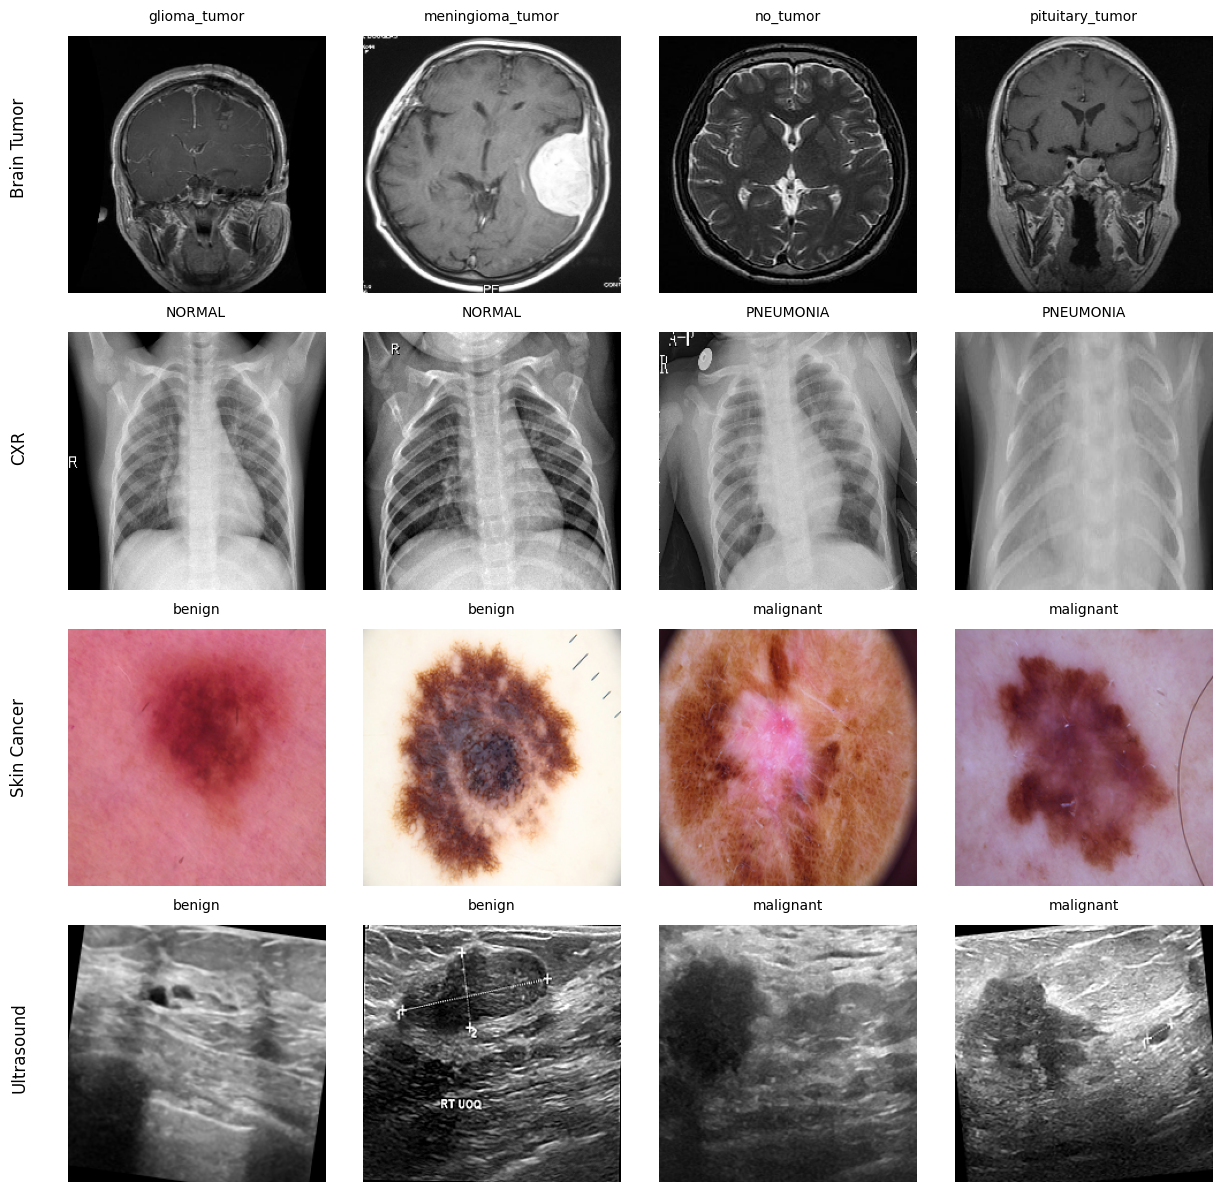

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import random
import os

# Dataset paths
dataset_info = {
    'Brain Tumor': '/content/brain-tumor-classification-mri-dataset/Training',
    'CXR': '/content/chest-xray-pneumonia/chest_xray/train',
    'Skin Cancer': '/content/skin-cancer/train',
    'Ultrasound': '/content/ultrasound/train'
}

# Loaders
def get_generator(path):
    datagen = ImageDataGenerator(rescale=1./255)
    return datagen.flow_from_directory(
        path,
        target_size=(224, 224),
        batch_size=64,
        class_mode='categorical',
        shuffle=True
    )

# Collect images per label
def get_labelwise_samples(generator, n_per_class):
    x, y = next(generator)
    labels = np.argmax(y, axis=1)
    label_to_images = {}
    for img, label in zip(x, labels):
        if label not in label_to_images:
            label_to_images[label] = []
        if len(label_to_images[label]) < n_per_class:
            label_to_images[label].append(img)
        if all(len(v) >= n_per_class for v in label_to_images.values()) and \
           len(label_to_images) >= generator.num_classes:
            break
    return label_to_images

# Plotting setup
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

# Loop over datasets
for idx, (name, path) in enumerate(dataset_info.items()):
    print(f"Processing {name}...")
    generator = get_generator(path)

    if name == 'Brain Tumor':
        label_to_images = get_labelwise_samples(generator, 1)
    else:
        label_to_images = get_labelwise_samples(generator, 2)

    label_ids = sorted(label_to_images.keys())
    images = []
    labels_for_images = []  # To store labels corresponding to images
    for label in label_ids:
        images.extend(label_to_images[label][:2] if name != 'Brain Tumor' else [label_to_images[label][0]])
        labels_for_images.extend([label] * (2 if name != 'Brain Tumor' else 1))

    # Mapping the label index to the class name
    class_indices = generator.class_indices
    index_to_class = {v: k for k, v in class_indices.items()}

    # Loop over each image and display it with the label on top
    for i in range(4):
        ax = axes[idx, i]
        ax.imshow(images[i])
        ax.axis('off')

        label_index = labels_for_images[i]
        label_name = index_to_class[label_index]
        ax.text(0.5, 1.05, label_name, ha='center', va='bottom', fontsize=10, color='black', transform=ax.transAxes)

    # Add dataset name to the left of each row
    fig.text(-0.01, 1 - (idx + 0.5) / 4, name, va='center', ha='right', rotation=90, fontsize=12)

plt.tight_layout()
plt.savefig('samples.pdf', format='pdf')
plt.show()

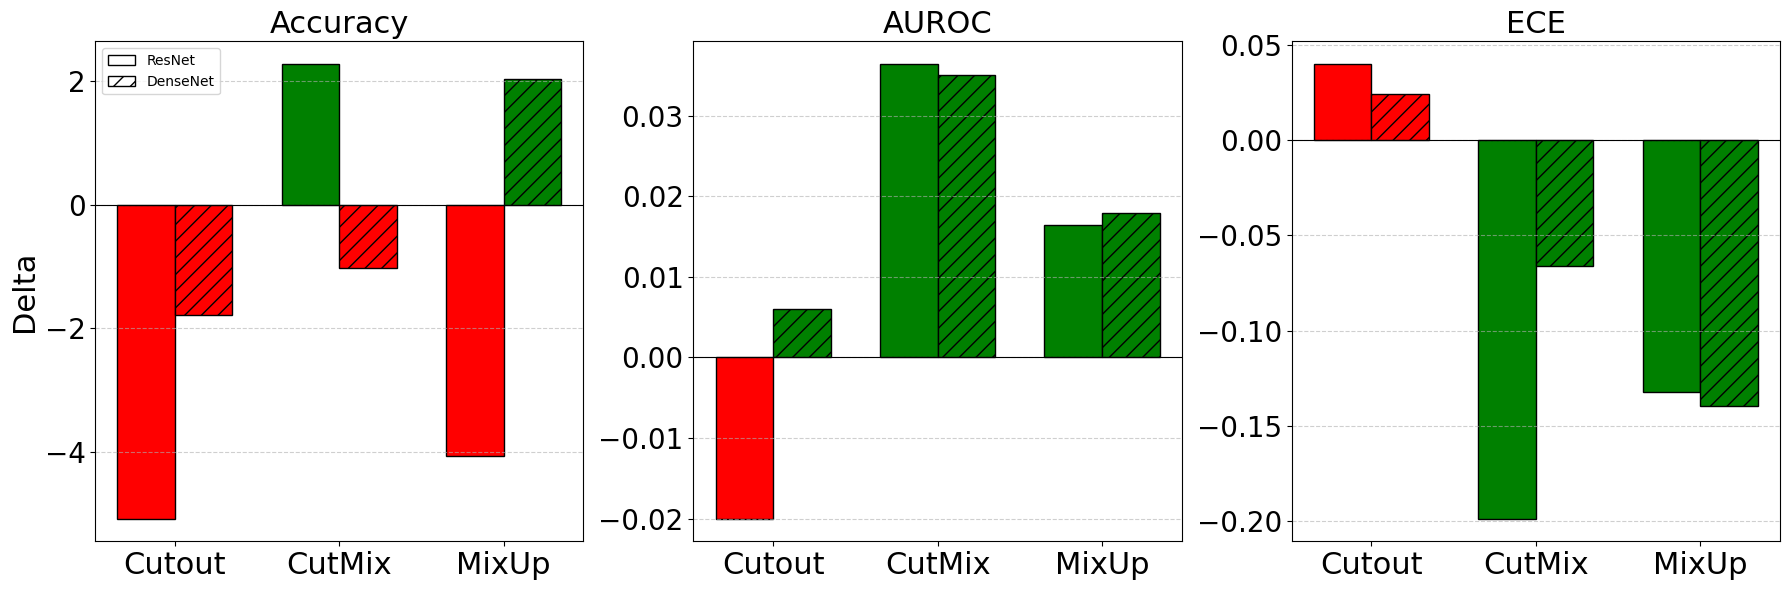

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Data
models = ["ResNet", "DenseNet"]
augmentations = ["Cutout", "CutMix", "MixUp"]
metrics = ["Accuracy", "AUROC", "ECE"]

# Baselines and augmented values
data = {
    "Accuracy": {
        "ResNet": [65.74, 60.66, 68.02, 61.68],
        "DenseNet": [72.34, 70.56, 71.32, 74.37]
    },
    "AUROC": {
        "ResNet": [0.84, 0.82, 0.8764, 0.8564],
        "DenseNet": [0.93, 0.9360, 0.9650, 0.9479]
    },
    "ECE": {
        "ResNet": [0.32, 0.36, 0.1214, 0.1880],
        "DenseNet": [0.24, 0.2645, 0.1739, 0.1006]
    }
}

# Function to compute deltas
def compute_deltas(metric, values):
    baseline = values[0]
    return [v - baseline for v in values[1:]]

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
bar_width = 0.35
x = np.arange(len(augmentations))

for i, metric in enumerate(metrics):
    ax = axs[i]

    for j, model in enumerate(models):
        deltas = compute_deltas(metric, data[metric][model])
        offset = j * bar_width
        # Determine color for delta and apply hatch for DenseNet
        bars = []
        for k, delta in enumerate(deltas):
            # Determine color
            if metric == "ECE":
                color = 'green' if delta < 0 else 'red'
            else:
                color = 'green' if delta > 0 else 'red'
            # Plot
            bar = ax.bar(x[k] + offset, delta, width=bar_width,
                         color=color,
                         hatch='//' if model == "DenseNet" else '',
                         edgecolor='black')
            bars.append(bar)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x + bar_width / 2)
    ax.set_xticklabels(augmentations, fontsize=22)
    ax.set_title(f"{metric}", fontsize=22)
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(axis='y', labelsize=20)

axs[0].set_ylabel("Delta", fontsize=22)
# Custom legend
legend_patches = [
    Patch(facecolor='white', edgecolor='black', label='ResNet'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='DenseNet'),
    # Patch(facecolor='green', label='Beneficial Change'),
    # Patch(facecolor='red', label='Harmful Change')
]
axs[0].legend(handles=legend_patches, loc='best')

plt.tight_layout()
plt.savefig("model_diff.pdf", format='pdf')
plt.show()

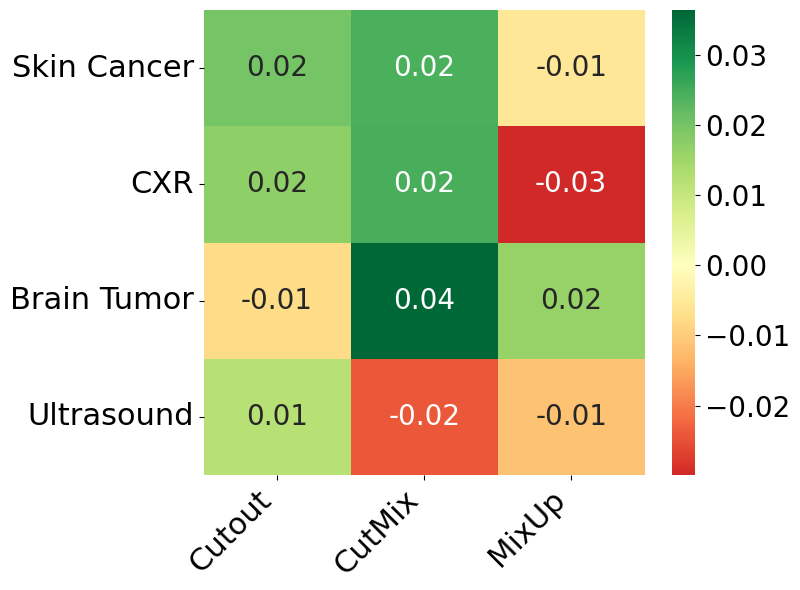

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Data for the table
datasets = ["Skin Cancer", "CXR", "Brain Tumor", "Ultrasound"]
augmentations = ["Cutout", "CutMix", "MixUp"]

# Baselines and augmented values
data = {
    "Skin Cancer": {
        "AUROC": [0.89, 0.91, 0.9143, 0.8846]
    },
    "CXR": {
        "AUROC": [0.86, 0.8772, 0.8847, 0.8301]
    },
    "Brain Tumor": {
        "AUROC": [0.84, 0.8323, 0.8764, 0.8564]
    },
    "Ultrasound": {
        "AUROC": [0.8799, 0.8921, 0.8557, 0.8685]
    }
}


def compute_deltas(metric, values):
    baseline = values[0]
    return [v - baseline for v in values[1:]]

def prepare_heatmap_data():
    heatmap_data = {}
    for dataset in datasets:
        deltas = compute_deltas("AUROC", data[dataset]["AUROC"])
        heatmap_data[dataset] = deltas
    df = pd.DataFrame(heatmap_data, index=augmentations)
    return df.T  # <-- Transpose so datasets are rows, augmentations are columns

fig, ax = plt.subplots(figsize=(8, 6))

df = prepare_heatmap_data()
heatmap = sns.heatmap(df, annot=True, cmap="RdYlGn", annot_kws={"size": 20}, center=0, fmt='.2f', ax=ax)

colorbar = heatmap.collections[0].colorbar
colorbar.ax.tick_params(labelsize=20)

# Set the title and labels
ax.set_xticklabels(augmentations, rotation=45, ha="right", fontsize=22)
ax.set_yticklabels(datasets, rotation=0, fontsize=22)

plt.tight_layout()
plt.savefig("AUROC.pdf", format='pdf')
plt.show()


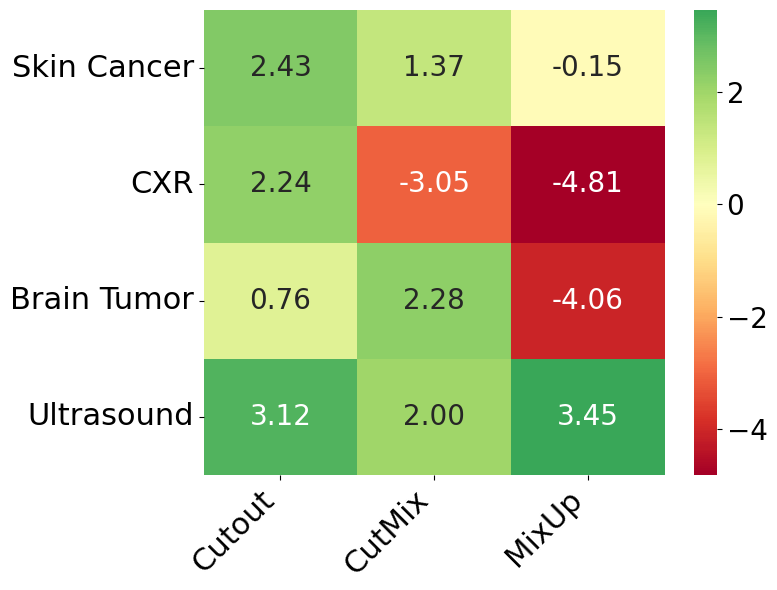

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Data for the table
datasets = ["Skin Cancer", "CXR", "Brain Tumor", "Ultrasound"]
augmentations = ["Cutout", "CutMix", "MixUp"]

# Baselines and augmented values
data = {
    "Skin Cancer": {
        "Accuracy": [80.45, 82.88, 81.82, 80.30]
    },
    "CXR": {
        "Accuracy": [80.61, 82.85, 77.56, 75.80]
    },
    "Brain Tumor": {
        "Accuracy": [65.74, 66.50, 68.02, 61.68]
    },
    "Ultrasound": {
        "Accuracy": [79.44, 82.56, 81.44, 82.89]
    }
}

# Compute deltas (difference from baseline)
def compute_deltas(metric, values):
    baseline = values[0]
    return [v - baseline for v in values[1:]]

# Prepare data for heatmap (for Accuracy)
def prepare_heatmap_data():
    heatmap_data = {}
    for dataset in datasets:
        deltas = compute_deltas("Accuracy", data[dataset]["Accuracy"])
        heatmap_data[dataset] = deltas
    df = pd.DataFrame(heatmap_data, index=augmentations)
    return df.T  # <-- Transpose so datasets are rows, augmentations are columns

# Create a figure for the heatmap
fig, ax = plt.subplots(figsize=(8, 6))

# Prepare and plot the heatmap for Accuracy
df = prepare_heatmap_data()
heatmap = sns.heatmap(df, annot=True, cmap="RdYlGn", annot_kws={"size": 20}, center=0, fmt='.2f', ax=ax)

colorbar = heatmap.collections[0].colorbar
colorbar.ax.tick_params(labelsize=20)

# Set the title and labels
ax.set_xticklabels(augmentations, rotation=45, ha="right", fontsize=22)
ax.set_yticklabels(datasets, rotation=0, fontsize=22)

plt.tight_layout()
plt.savefig("accuracy.pdf", format='pdf')
plt.show()


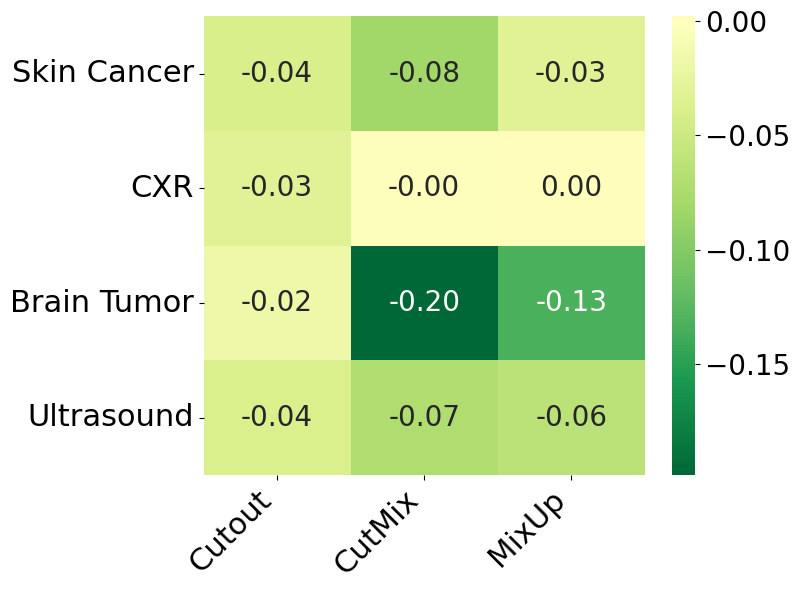

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Data for the table
datasets = ["Skin Cancer", "CXR", "Brain Tumor", "Ultrasound"]
augmentations = ["Cutout", "CutMix", "MixUp"]

# Baselines and augmented values
data = {
    "Skin Cancer": {
        "ECE": [0.17, 0.13, 0.0879, 0.1373]
    },
    "CXR": {
        "ECE": [0.19, 0.1572, 0.1870, 0.1921]
    },
    "Brain Tumor": {
        "ECE": [0.32, 0.3014, 0.1214, 0.1880]
    },
    "Ultrasound": {
        "ECE": [0.1917, 0.1545, 0.1189, 0.1294]
    }
}

# Compute deltas (difference from baseline)
def compute_deltas(metric, values):
    baseline = values[0]
    return [v - baseline for v in values[1:]]

def prepare_heatmap_data():
    heatmap_data = {}
    for dataset in datasets:
        deltas = compute_deltas("ECE", data[dataset]["ECE"])
        heatmap_data[dataset] = deltas
    df = pd.DataFrame(heatmap_data, index=augmentations)
    return df.T  # <-- Transpose so datasets are rows, augmentations are columns

# Create a figure for the heatmap
fig, ax = plt.subplots(figsize=(8, 6))

df = prepare_heatmap_data()
heatmap = sns.heatmap(df, annot=True, cmap="RdYlGn_r", annot_kws={"size": 20}, center=0, fmt='.2f', ax=ax)

colorbar = heatmap.collections[0].colorbar
colorbar.ax.tick_params(labelsize=20)

# Set the title and labels
ax.set_xticklabels(augmentations, rotation=45, ha="right", fontsize=22)
ax.set_yticklabels(datasets, rotation=0, fontsize=22)

plt.tight_layout()
plt.savefig("ECE.pdf", format='pdf')
plt.show()